In [ ]:
import os
import openpyxl
from openpyxl.utils import range_boundaries

def clean_excel_files(source_folder, dest_folder):
    for root, dirs, files in os.walk(source_folder):
        for filename in files:
            if filename.endswith('.xlsx') and not filename.startswith('~$'):
                input_file_path = os.path.join(root, filename)
                relative_path = os.path.relpath(root, source_folder)
                output_dir_path = os.path.join(dest_folder, relative_path)
                output_file_path = os.path.join(output_dir_path, filename)

                if not os.path.exists(output_dir_path):
                    os.makedirs(output_dir_path)

                print(f"Processing: {input_file_path}")

                try:
                    wb = openpyxl.load_workbook(input_file_path, data_only=False)
                    sheet_modified = False

                    for sheet_name in wb.sheetnames:
                        # ROA setup
                        scanned_rows = set()
                        sheet = wb[sheet_name]

                        max_row_scan = min(6, sheet.max_row)

                        for row_idx in range(1, max_row_scan + 1):
                            for cell in sheet[row_idx]:
                                if cell.value and "ROA" in str(cell.value).upper():
                                    scanned_rows.add(cell.column)
                        
                        scanned_columns = list(scanned_rows)
                        if not scanned_columns:
                            print(f"  - No 'ROA' columns found in sheet '{sheet_name}' (rows 1-6)")
                            continue

                        print(f"  - Found ROA columns in sheet '{sheet_name}': {scanned_columns}")
                        start_row = 7

                        rows_to_remove = []

                        for row_idx in range(sheet.max_row, start_row - 1, -1):
                            # row_data = list(sheet.iter_rows(min_row=row_idx, max_row=row_idx, values_only=True))[0]
                            remove_this_row = False

                            for col_idx in scanned_columns:
                                cell_getter = sheet.cell(row=row_idx, column=col_idx)
                                cell_val = cell_getter.value

                                if cell_val is None:
                                    continue
                                if isinstance(cell_val, (int, float)) and cell_val == 0:
                                    remove_this_row = True
                                    break
                                if isinstance(cell_val, str) and cell_val.strip().upper() == "NA":
                                    remove_this_row = True
                                    break

                            if remove_this_row:
                                rows_to_remove.append(row_idx)

                        if rows_to_remove:
                            rows_to_remove.sort(reverse=True)
                            for row_idx in rows_to_remove:
                                sheet.delete_rows(row_idx, 1)
                            sheet_modified = True
                            print(f"  - Removed {len(rows_to_remove)} rows from sheet '{sheet_name}'")

                    wb.save(output_file_path)
                    if sheet_modified:
                        print(f"  -> Saved cleaned file to: {output_file_path}")
                    else:
                        print(f"  -> No changes needed. Saved copy to: {output_file_path}")

                except Exception as e:
                    print(f"Error processing file {filename}: {e}")

source_directory = "E:\\hneu\\data2"
destination_directory = "E:\\hneu\\data4"

if __name__ == "__main__":
    if os.path.exists(source_directory):
        clean_excel_files(source_directory, destination_directory)
        print("\nAll files processed successfully.")
    else:
        print(f"Error: Source directory '{source_directory}' does not exist.")


# Preprocessing data

In [6]:
from openpyxl import load_workbook
import pandas as pd
from pathlib import Path
import re
import os

capex_dir = Path("E:/hneu/xlsm_data/data_tong_hop")
capex_files = list(capex_dir.glob("*.xlsm"))
print(f"Found {len(capex_files)} files.")

def extract_capex_from_sheet(worksheet, sector):
    """
    Extract data from a worksheet that has columns:
    Col A: Country, Col B: Financial Year, Col C: Capex
    Assumes first row is header.
    Returns list of dicts.
    """
    data = []
    for row in worksheet.iter_rows(min_row=2, values_only=True):
        country, year, capex = row[0], row[1], row[2]

        if country is None or capex is None or year is None:
            continue
            
        try:
            year_match = re.match("FY(\d{4})", year)
            year = int(year_match.group(1))
            if year < 2014 or year > 2024:
                raise ValueError("Not in the valid year range: 2014 to 2024")
        except (TypeError, ValueError):
            year = None
            print("Flagged for year range error")
    
        if isinstance(capex, str):
            capex = capex.replace(',', '').replace('(', '-').replace(')', '')
        try:
            capex = float(capex)
        except (TypeError, ValueError):
            capex = None
        
        if year >= 2014 and year <= 2024:
            data.append({
                "Country": country.strip() if isinstance(country, str) else country,
                "Sector": sector,
                "Year": year,
                "Capex": capex
            })
        
    return data

all_data = []
for file in capex_files:
    print(f"Processing {file.name}...")

    sector = os.path.splitext(file.name)[0]
    try:
        wb = load_workbook(file, read_only=True, data_only=True)
        
        if 'final' not in wb.sheetnames:
            print(f"Skipping {file.name}...")
            wb.close()
            continue
    
        final_sheet = wb['final']
        file_data = extract_capex_from_sheet(final_sheet, sector=sector)
        all_data.extend(file_data)
        wb.close()
    except Exception as e:
        print(f"Error processing {file.name}: {e}")

df = pd.DataFrame(all_data)
df.to_csv("E:\\hneu\\notebooks\\model_results\\capex_data.csv")

Found 5 files.
Processing Energy.xlsm...
Processing Healthcare.xlsm...
Processing Industrials.xlsm...
Processing Materials.xlsm...
Processing Real_Estate.xlsm...


In [ ]:
from openpyxl import load_workbook
import pandas as pd
from pathlib import Path
import os
import re

risk_dir = Path("E:\\hneu\\xlsm_data\\inform_risk")
risk_files = list(risk_dir.glob("*.xlsx"))
print(f"Found {len(risk_files)} files.")

def extract_risk_from_sheet(worksheet, source_file):
    """
    Extract data from a worksheet that has columns:
    Col A: Iso3, Col B: IndicatorName, Col C: INFORMYear, Col D: IndicatorScore
    Assumes first row is header.
    Returns list of dicts.
    """
    data = []
    for row in worksheet.iter_rows(min_row=2, values_only=True):
        iso3, indicator_name, year, score = row[0], row[1], row[2], row[3]

        if iso3 is None or year is None or score is None:
            continue
            
        try:
            year_match = re.search(r'\d{4}', str(year))
            if year_match:
                year = int(year_match.group())
            else:
                raise ValueError("No year found")
            
            if year < 2014 or year > 2025:
                raise ValueError("Not in the valid year range: 2014 to 2024")
        except (TypeError, ValueError) as e:
            print(f"Flagged for year range error: {year} - {e}")
            continue  # Skip this row entirely
    
        if isinstance(score, str):
            score = score.replace(',', '')
        try:
            score = float(score)
        except (TypeError, ValueError):
            score = None
        
        data.append({
            "Iso3": iso3.strip() if isinstance(iso3, str) else iso3,
            "IndicatorName": indicator_name.strip() if isinstance(indicator_name, str) else indicator_name,
            "Source": source_file,
            "Year": year,
            "IndicatorScore": score
        })
        
    return data

def extract_country_id_from_sheet(worksheet):
    """
    Extract country ID mapping from worksheet.
    Col A: country, Col B: country id
    Assumes first row is header.
    Returns list of dicts.
    """
    data = []
    for row in worksheet.iter_rows(min_row=2, values_only=True):
        country, country_id = row[0], row[1]

        if country is None or country_id is None:
            continue
        
        data.append({
            "country": country.strip() if isinstance(country, str) else country,
            "country_id": country_id.strip() if isinstance(country_id, str) else country_id
        })
        
    return data

all_data = []
country_mapping = []

for file in risk_files:
    print(f"Processing {file.name}...")

    source = os.path.splitext(file.name)[0]
    try:
        wb = load_workbook(file, read_only=True, data_only=True)
        
        if 'INFORM RISK INDEX' in wb.sheetnames:
            risk_sheet = wb['INFORM RISK INDEX']
            file_data = extract_risk_from_sheet(risk_sheet, source)
            all_data.extend(file_data)
        
        if 'country_id' in wb.sheetnames and not country_mapping:
            country_sheet = wb['country_id']
            country_data = extract_country_id_from_sheet(country_sheet)
            country_mapping.extend(country_data)
        
        wb.close()
    except Exception as e:
        print(f"Error processing {file.name}: {e}")

df_risk = pd.DataFrame(all_data)
df_country = pd.DataFrame(country_mapping)

if not df_country.empty and not df_risk.empty:
    df_combined = pd.merge(df_risk, df_country, left_on='Iso3', right_on='country_id', how='left')
    df_combined.to_csv("E:\\hneu\\notebooks\\model_results\\inform_risk_data.csv", index=False)
else:
    print("No data to combine")
    df_risk.to_csv("E:\\hneu\\notebooks\\model_results\\inform_risk_data.csv", index=False)

Found 1 files.
Processing inform_risk.xlsx...


: 

In [9]:
from openpyxl import load_workbook
import pandas as pd
from pathlib import Path
import os

risk_dir = Path("E:/hneu/xlsm_data/inform_risk")
risk_files = list(risk_dir.glob("*.xlsx"))
print(f"Found {len(risk_files)} files.")

def extract_risk_data(worksheet, risk_type):
    """
    Extract data from a worksheet with years in column A (starting row 2)
    and country names in row 1 (starting col B).
    Returns list of dicts: Country, RiskType, Year, Value.
    """
    data = []
    
    countries = []
    for cell in worksheet[1][1:]:
        if cell.value:
            countries.append(str(cell.value).strip())
    
    for row in worksheet.iter_rows(min_row=2, values_only=True):
        year_val = row[0]
        if year_val is None:
            continue
        
        # Parse year
        try:
            year = int(year_val)
            if year < 2014 or year > 2025:
                print(f"Year {year} out of expected range (2014-2025)")
                continue
        except (TypeError, ValueError):
            print(f"Invalid year value: {year_val}")
            continue
        
        for idx, value in enumerate(row[1:]):
            if value is None:
                continue
            country = countries[idx] if idx < len(countries) else None
            if country is None:
                continue
            
            if isinstance(value, str):
                value = value.replace(',', '')
            try:
                num_value = float(value)
            except (TypeError, ValueError):
                print(f"Non-numeric value for {country} {year}: {value}")
                continue
            
            data.append({
                "Country": country,
                "RiskType": risk_type,
                "Year": year,
                "Value": num_value
            })
    
    return data

all_data = []

for file in risk_files:
    print(f"Processing {file.name}...")
    
    risk_type = os.path.splitext(file.name)[0].replace("Risk", "").strip()
    
    try:
        wb = load_workbook(file, read_only=True, data_only=True)
        
        if 'final' not in wb.sheetnames:
            print(f"No 'final' sheet in {file.name}, skipping.")
            wb.close()
            continue
        
        sheet = wb['final']
        file_data = extract_risk_data(sheet, risk_type)
        all_data.extend(file_data)
        wb.close()
    except Exception as e:
        print(f"Error processing {file.name}: {e}")

df = pd.DataFrame(all_data)
output_path = "E:\\hneu\\notebooks\\model_results\\inform_risk_combined.csv"
df.to_csv(output_path, index=False)
print(f"Saved {len(df)} records to {output_path}")

Found 2 files.
Processing PhysicalRisk.xlsx...
Processing TransitionRisk.xlsx...
Saved 2375 records to E:\hneu\notebooks\model_results\inform_risk_combined.csv


In [4]:
from openpyxl import load_workbook
import pandas as pd
from pathlib import Path
import os

zscore_dir = Path("E:/hneu/xlsm_data/z_score_npl")
zscore_files = list(zscore_dir.glob("*.xlsm"))
print(f"Found {len(zscore_files)} files.")

def extract_zscore_from_sheet(worksheet, source_file):
    """
    Extract data from a worksheet that has columns:
    Col A: z-score (constant), Col B: Country, Col C: Year, Col D: Score
    Assumes first row is header.
    Returns list of dicts.
    """
    data = []
    for row in worksheet.iter_rows(min_row=2, values_only=True):
        country, year, score =  row[0], row[1], row[2]
        indicator = "NPL_Score"

        if country is None or year is None or score is None:
            continue
            
        try:
            year = int(year)
            if year < 2014 or year > 2024:
                raise ValueError("Not in the valid year range: 2014 to 2024")
        except (TypeError, ValueError):
            year = None
            print("Flagged for year range error")
    
        if isinstance(score, str):
            score = score.replace(',', '')
        try:
            score = float(score)
        except (TypeError, ValueError):
            score = None
        
        if year >= 2014 and year <= 2024:
            data.append({
                "Country": country.strip() if isinstance(country, str) else country,
                "Indicator": indicator.strip() if isinstance(indicator, str) else indicator,
                "Source": source_file,
                "Year": year,
                "ZScore": score
            })
        
    return data

def extract_country_id_from_sheet(worksheet):
    """
    Extract country ID mapping from worksheet.
    Col A: country, Col B: country id
    Assumes first row is header.
    Returns list of dicts.
    """
    data = []
    for row in worksheet.iter_rows(min_row=2, values_only=True):
        country, country_id = row[0], row[1]

        if country is None or country_id is None:
            continue
        
        data.append({
            "country": country.strip() if isinstance(country, str) else country,
            "country_id": country_id.strip() if isinstance(country_id, str) else country_id
        })
        
    return data

all_data = []
country_mapping = []

for file in zscore_files:
    print(f"Processing {file.name}...")

    source = os.path.splitext(file.name)[0]
    try:
        wb = load_workbook(file, read_only=True, data_only=True)
        
        if 'final' in wb.sheetnames:
            zscore_sheet = wb['final']
            file_data = extract_zscore_from_sheet(zscore_sheet, source)
            all_data.extend(file_data)
        
        if 'country_id' in wb.sheetnames and not country_mapping:
            country_sheet = wb['country_id']
            country_data = extract_country_id_from_sheet(country_sheet)
            country_mapping.extend(country_data)
        
        wb.close()
    except Exception as e:
        print(f"Error processing {file.name}: {e}")

df_zscore = pd.DataFrame(all_data)
df_country = pd.DataFrame(country_mapping)

if not df_country.empty and not df_zscore.empty:
    df_combined = pd.merge(df_zscore, df_country, left_on='Country', right_on='country', how='left')
    df_combined.to_csv("E:\\hneu\\notebooks\\model_results\\npl_score_data.csv", index=False)
else:
    print("No data to combine or no country mapping available")
    df_zscore.to_csv("E:\\hneu\\notebooks\\model_results\\npl_score_data.csv", index=False)
    
print(f"Processed {len(all_data)} z-score records")

Found 1 files.
Processing BANK NPL FINAL toan nganh.xlsm...
No data to combine or no country mapping available
Processed 495 z-score records


# Model inference

In [ ]:
# %%
# Install if needed: pip install linearmodels statsmodels pandas openpyxl

import pandas as pd
import numpy as np
import warnings
from linearmodels.panel import PanelOLS, RandomEffects, PooledOLS
from statsmodels.stats.diagnostic import het_breuschpagan
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.4f' % x)

# %%
capex_df = pd.read_csv("E:\\hneu\\notebooks\\model_results\\capex_data.csv")
risk_df = pd.read_csv("E:\\hneu\\notebooks\\model_results\\inform_risk_combined.csv")
zscore_df = pd.read_csv("E:\\hneu\\notebooks\\model_results\\npl_score_data.csv")

print(f"CAPEX records: {len(capex_df)} | Risk records: {len(risk_df)} | Z-score records: {len(zscore_df)}")

# %%
def standardize_country_name(name):
    if pd.isna(name):
        return None
    return str(name).strip().upper().replace(' ', '_')

capex_df['Country_std'] = capex_df['Country'].apply(standardize_country_name)
risk_df['Country_std'] = risk_df['country'].apply(standardize_country_name)
zscore_df['Country_std'] = zscore_df['Country'].apply(standardize_country_name)

risk_filtered = risk_df[risk_df['IndicatorName'].str.contains('INFORM Risk Index', case=False, na=False)].copy()
risk_filtered = risk_filtered[['Country_std', 'Year', 'IndicatorScore']].rename(
    columns={'IndicatorScore': 'INFORM_Risk'})

capex_pivot = capex_df.pivot_table(
    index=['Country_std', 'Year'], 
    columns='Sector', 
    values='Capex', 
    aggfunc='mean'
).reset_index()

capex_pivot.columns = ['Country_std', 'Year'] + [f"CAPEX_{col.upper()}" for col in capex_pivot.columns[2:]]

panel_df = capex_pivot.merge(risk_filtered, on=['Country_std', 'Year'], how='left')
panel_df = panel_df.merge(zscore_df[['Country_std', 'Year', 'ZScore']], on=['Country_std', 'Year'], how='left')

panel_df = panel_df.dropna(subset=['INFORM_Risk', 'ZScore'])

panel_df = panel_df.set_index(['Country_std', 'Year'])
panel_df = panel_df.sort_index()

print(f"\n✅ Final panel: {panel_df.shape[0]} observations | {panel_df.index.get_level_values('Country_std').nunique()} countries | {panel_df.index.get_level_values('Year').nunique()} years")
print(f"Columns: {panel_df.columns.tolist()}")


# %%
def run_stage1_panel(capex_col, df, add_controls=True):
    """
    Run PanelOLS: CAPEX_sector ~ INFORM_Risk [+ controls]
    Returns fitted model results
    """
    data = df[[capex_col, 'INFORM_Risk']].dropna()
    
    if add_controls:
        data = data.copy()
        data['Year'] = data.index.get_level_values('Year')
        data = pd.get_dummies(data, columns=['Year'], drop_first=True)
    
    Y = data[capex_col]
    X = data.drop(columns=[capex_col])
    X = X.dropna()
    Y = Y.loc[X.index]
    
    from statsmodels.tools import add_constant
    X = add_constant(X)
    
    mod = PanelOLS(Y, X, entity_effects=True)
    res = mod.fit(cov_type='clustered', cluster_entity=True)
    
    return res

capex_cols = [c for c in panel_df.columns if c.startswith('CAPEX_')]
print(f"CAPEX sectors to analyze: {capex_cols}")

stage1_results = {}
for col in capex_cols:
    print(f"\n🔹 Running Stage 1: {col} ~ INFORM_Risk")
    try:
        res = run_stage1_panel(col, panel_df)
        stage1_results[col] = {
            'coef_inform': res.params.get('INFORM_Risk', np.nan),
            'pvalue_inform': res.pvalues.get('INFORM_Risk', np.nan),
            'r2_within': res.rsquared_within,
            'nobs': res.nobs,
            'model': res
        }
        print(f"   β(INFORM) = {res.params.get('INFORM_Risk', np.nan):.4f}, p = {res.pvalues.get('INFORM_Risk', np.nan):.4f}")
    except Exception as e:
        print(f"   ❌ Error: {e}")
        stage1_results[col] = None

panel_stage2 = panel_df.copy()

for col in capex_cols:
    if stage1_results[col] is not None:
        model = stage1_results[col]['model']
        panel_stage2[f"{col}_fitted"] = model.fitted_values
    else:
        panel_stage2[f"{col}_fitted"] = np.nan

stage2_vars = [c for c in panel_stage2.columns if '_fitted' in c] + ['INFORM_Risk', 'ZScore']
panel_stage2 = panel_stage2[stage2_vars].dropna()

print(f"\n✅ Stage 2 data ready: {panel_stage2.shape} | Columns: {panel_stage2.columns.tolist()}")

# %%
def run_all_three_models(Y, X, entity_col='Country_std', time_col='Year'):
    """
    Run OLS (Pooled), FEM, REM using linearmodels
    Returns dict of results
    """
    from statsmodels.tools import add_constant
    
    if not isinstance(X.index, pd.MultiIndex):
        X = X.set_index([entity_col, time_col])
        Y = Y.set_index([entity_col, time_col])
    
    X = add_constant(X)
    
    results = {}
    
    print("  → Running Pooled OLS...")
    pooled_mod = PooledOLS(Y, X)
    results['OLS'] = pooled_mod.fit(cov_type='robust')
    
    print("  → Running Fixed Effects Model (FEM)...")
    fe_mod = PanelOLS(Y, X, entity_effects=True, time_effects=False)
    results['FEM'] = fe_mod.fit(cov_type='clustered', cluster_entity=True)
    
    print("  → Running Random Effects Model (REM)...")
    re_mod = RandomEffects(Y, X)
    results['REM'] = re_mod.fit(cov_type='robust')
    
    return results

Y_stage2 = panel_stage2['ZScore']
X_stage2 = panel_stage2[[c for c in panel_stage2.columns if c.endswith('_fitted')]].copy()

# X_stage2['INFORM_Risk'] = panel_stage2['INFORM_Risk']

print("\n" + "="*80)
print("STAGE 2: Running OLS / FEM / REM for Z-Score ~ CAPEX_fitted")
print("="*80)
stage2_results = run_all_three_models(Y_stage2, X_stage2)

# %%
def compare_models(results_dict):
    """Compare coefficients, p-values, R² across OLS/FEM/REM"""
    
    comparison = []
    
    for model_name, res in results_dict.items():
        row = {
            'Model': model_name,
            'R²': res.rsquared,
            'R² Within': getattr(res, 'rsquared_within', np.nan),
            'R² Between': getattr(res, 'rsquared_between', np.nan),
            'Observations': res.nobs,
            'Entities': getattr(res, 'nentity', np.nan),
            'F-statistic': res.f_statistic if hasattr(res, 'f_statistic') else np.nan,
            'F-pvalue': res.f_pvalue if hasattr(res, 'f_pvalue') else np.nan,
        }
        for var in results_dict['OLS'].params.index:
            if var != 'const':
                row[f'{var}_coef'] = res.params.get(var, np.nan)
                row[f'{var}_pval'] = res.pvalues.get(var, np.nan)
        comparison.append(row)
    
    return pd.DataFrame(comparison)

comparison_df = compare_models(stage2_results)
print("\n📊 Model Comparison Summary:")
print(comparison_df.to_string())

comparison_df.to_csv("E:\\hneu\\notebooks\\model_results\\model_comparison.csv", index=False)

CAPEX records: 2299 | Risk records: 1910 | Z-score records: 495

✅ Final panel: 351 observations | 39 countries | 9 years
Columns: ['CAPEX_ENERGY', 'CAPEX_HEALTHCARE', 'CAPEX_INDUSTRIALS', 'CAPEX_MATERIALS', 'CAPEX_REAL_ESTATE', 'INFORM_Risk', 'ZScore']
CAPEX sectors to analyze: ['CAPEX_ENERGY', 'CAPEX_HEALTHCARE', 'CAPEX_INDUSTRIALS', 'CAPEX_MATERIALS', 'CAPEX_REAL_ESTATE']

🔹 Running Stage 1: CAPEX_ENERGY ~ INFORM_Risk
   β(INFORM) = 10942077.1014, p = 0.2284

🔹 Running Stage 1: CAPEX_HEALTHCARE ~ INFORM_Risk
   β(INFORM) = 1332354.2105, p = 0.1850

🔹 Running Stage 1: CAPEX_INDUSTRIALS ~ INFORM_Risk
   β(INFORM) = 3672512.7452, p = 0.2740

🔹 Running Stage 1: CAPEX_MATERIALS ~ INFORM_Risk
   β(INFORM) = 7546578.0639, p = 0.2100

🔹 Running Stage 1: CAPEX_REAL_ESTATE ~ INFORM_Risk
   β(INFORM) = -881536.1854, p = 0.2016

✅ Stage 2 data ready: (99, 7) | Columns: ['CAPEX_ENERGY_fitted', 'CAPEX_HEALTHCARE_fitted', 'CAPEX_INDUSTRIALS_fitted', 'CAPEX_MATERIALS_fitted', 'CAPEX_REAL_ESTATE_fit

CLIMATE RISK SPILLOVER ANALYSIS PIPELINE
Execution Time: 2026-03-12 18:15:02
Output Directory: E:\hneu\notebooks\model_results\output

=====================🚀 STARTING COMPLETE ANALYSIS PIPELINE======================


STEP 1: DATA LOADING & PREPROCESSING

📂 Loading datasets...
  ✓ CAPEX records: 2,299
  ✓ Risk records: 2,375
  ✓ Bank Stability records: 495

📊 After year filtering (2014-2024):
  ✓ CAPEX: 2,299 | Risk: 2,198 | Z-Score: 495

🔄 Pivoting CAPEX data by sector...
  ✓ CAPEX columns: ['CAPEX_ENERGY', 'CAPEX_HEALTHCARE', 'CAPEX_INDUSTRIALS', 'CAPEX_MATERIALS', 'CAPEX_REAL_ESTATE']

🔄 Separating Physical and Transition Risk...
  Available RiskTypes: <ArrowStringArray>
['Physical', 'Transition']
Length: 2, dtype: str
  ✓ Physical Risk records: 1,593
  ✓ Transition Risk records: 605

🔄 Merging datasets...

📊 Final Panel Data:
  ✓ Observations: 297 (dropped 264 due to missing values)
  ✓ Countries: 33
  ✓ Years: 9
  ✓ CAPEX Sectors: 5
  ✓ Columns: ['CAPEX_ENERGY', 'CAPEX_HEALTHCARE'

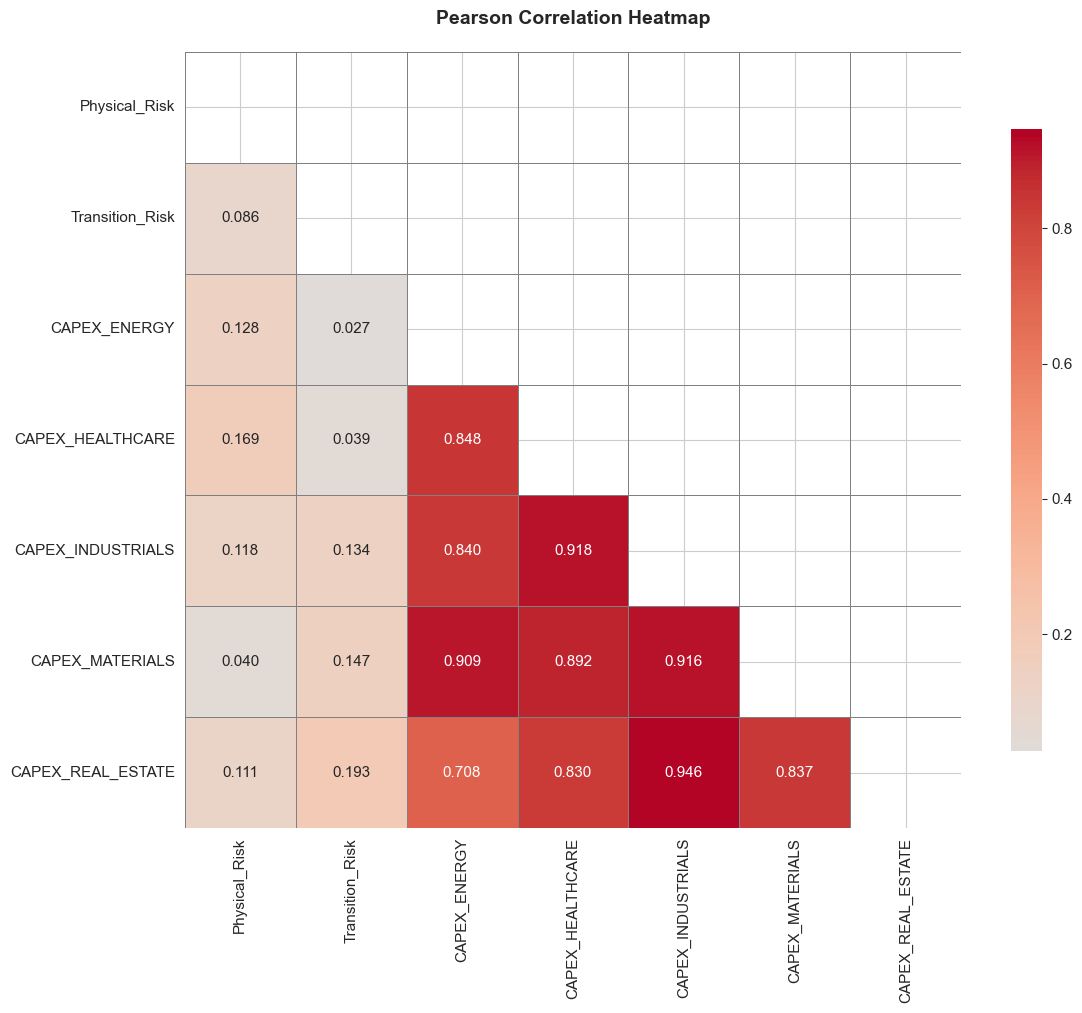

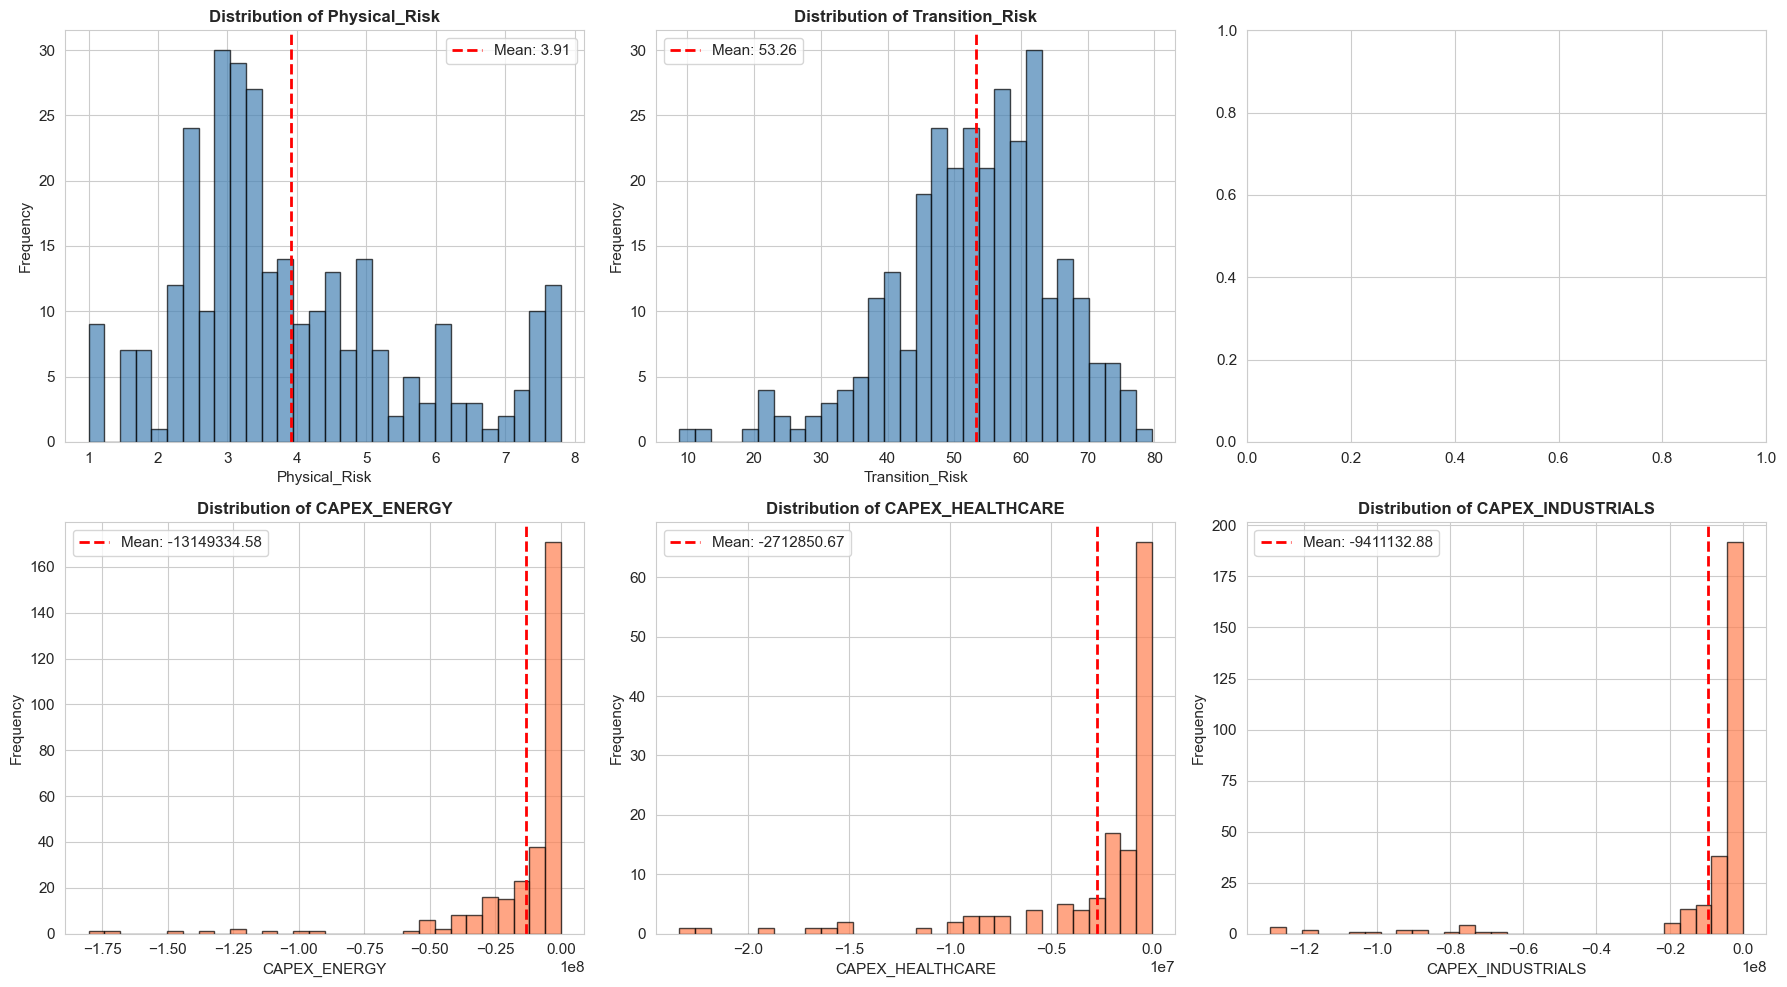


🔍 VARIANCE INFLATION FACTOR (VIF) ANALYSIS
--------------------------------------------------------------------------------
       Variable       VIF  Tolerance Severity
          const 25.017827   0.039971     High
  Physical_Risk  1.007409   0.992645      Low
Transition_Risk  1.007409   0.992645      Low


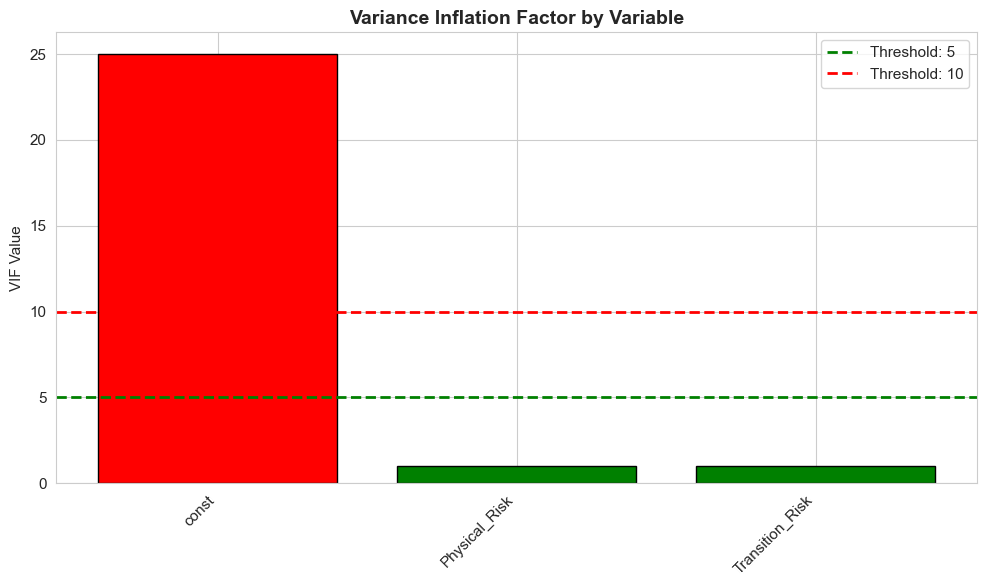


⚠️  WARNING: 1 variables with high multicollinearity (VIF > 10)

STEP 3: STAGE 1 - CLIMATE RISK → CAPEX BY SECTOR
Model: CAPEX_sector = β1*Physical_Risk + β2*Transition_Risk + Controls + ε

SECTOR: ENERGY

📊 Model Comparison for CAPEX_ENERGY:
--------------------------------------------------------------------------------
Model      R²           Physical_β      p-value      Transition_β    p-value     
--------------------------------------------------------------------------------
OLS        0.0168       1878704.522002  0.0000       34599.176475    0.7094      
FEM        0.0158       -3716355.049321 0.0357       -21674.535075   0.7365      
REM        0.0053       -1846236.286966 0.0641       -17540.772601   0.7935      

SECTOR: HEALTHCARE

📊 Model Comparison for CAPEX_HEALTHCARE:
--------------------------------------------------------------------------------
Model      R²           Physical_β      p-value      Transition_β    p-value     
-----------------------------------------

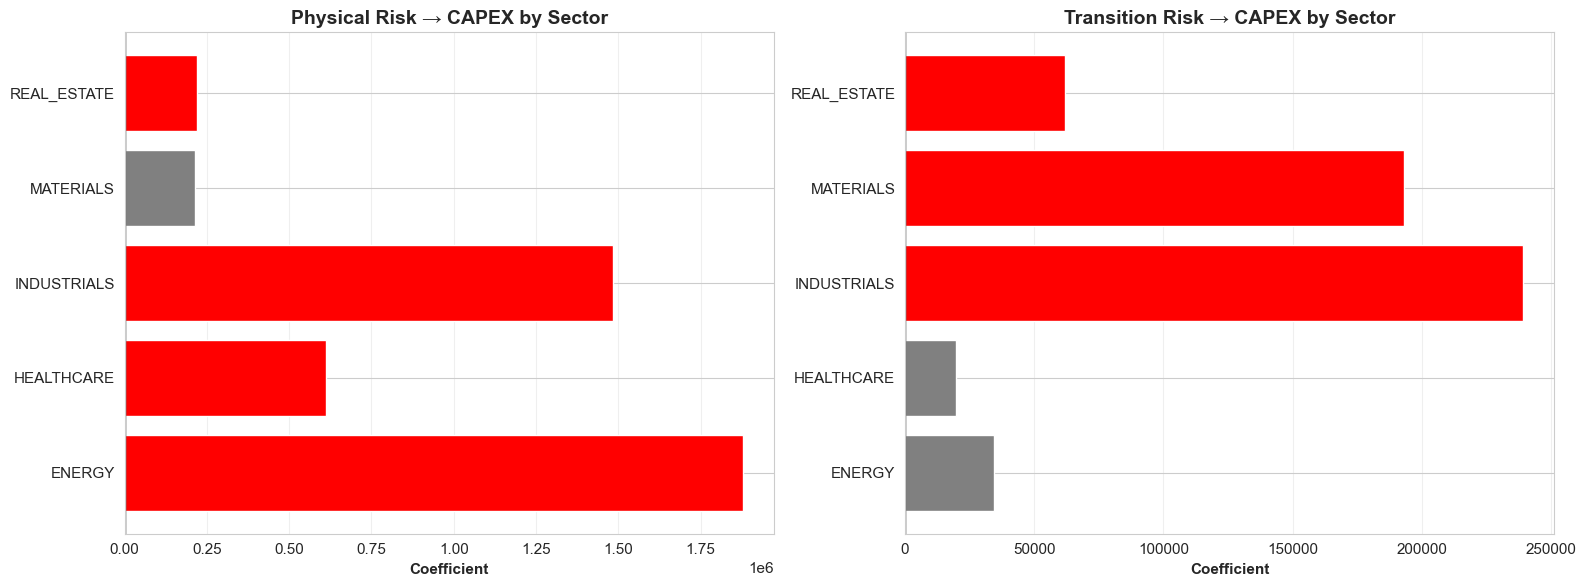


📈 Creating Stage 2 model comparison plot...

📈 Creating model fit comparison...

⚠️ Skipping model fit comparison plot because no fit statistics are available.

💾 All visualizations saved to: E:\hneu\notebooks\model_results\output

STEP 7: GENERATING FINAL REPORT
✅ Final report saved to: E:\hneu\notebooks\model_results\output\analysis_report.txt

PIPELINE COMPLETED SUCCESSFULLY

📁 Output Directory: E:\hneu\notebooks\model_results\output

📄 Key Files Generated:
  • panel_data_preprocessed.csv
  • descriptive_statistics.csv
  • correlation_matrix.csv
  • vif_analysis.csv
  • stage1_summary.csv
  • stage2_model_comparison.csv
  • specification_tests.csv
  • analysis_report.txt

📊 Visualizations:
  • correlation_heatmap.png
  • distribution_plots.png
  • vif_chart.png
  • stage1_coefficients.png
  • stage2_coefficient_comparison.png
  • model_fit_comparison.png

🏆 Preferred Model: FEM

✅ All tasks completed!


In [14]:
# =============================================================================
# CLIMATE RISK SPILLOVER ANALYSIS: COMPLETE PIPELINE
# Stage 1: CAPEX(Sector) = β1*PhysicalRisk + β2*TransitionRisk + ε
# Stage 2: Bank Stability = θ*CAPEX_fitted + ε
# Models: Pooled OLS, Fixed Effects (FEM), Random Effects (REM)
# =============================================================================

# %% [markdown]
# # 1. LIBRARY IMPORTS & CONFIGURATION
# =============================================================================

import pandas as pd
import numpy as np
import warnings
from pathlib import Path
import os
from datetime import datetime

# Econometrics libraries
from linearmodels.panel import PanelOLS, RandomEffects, PooledOLS
# from linearmodels.panel.utility import panel_structure
from statsmodels.tools import add_constant
from statsmodels.stats.diagnostic import het_breuschpagan
from scipy import stats

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Warnings & display settings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', None)
pd.set_option('display.float_format', lambda x: '%.6f' % x)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 11

# Output directory
OUTPUT_DIR = Path("E:\\hneu\\notebooks\\model_results\\output")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("="*80)
print("CLIMATE RISK SPILLOVER ANALYSIS PIPELINE")
print("="*80)
print(f"Execution Time: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Output Directory: {OUTPUT_DIR}")
print("="*80)


# %% [markdown]
# # 2. DATA LOADING & PREPROCESSING
# =============================================================================

def load_and_preprocess_data():
    """
    Load all CSV files and prepare panel data structure
    Returns: panel_df (Country-Year panel with all variables)
    """
    
    print("\n" + "="*80)
    print("STEP 1: DATA LOADING & PREPROCESSING")
    print("="*80)
    
    # File paths
    CAPEX_PATH = "E:\\hneu\\notebooks\\model_results\\capex_data.csv"
    RISK_PATH = "E:\\hneu\\notebooks\\model_results\\inform_risk_combined.csv"
    ZSCORE_PATH = "E:\\hneu\\notebooks\\model_results\\npl_score_data.csv"
    
    # Load datasets
    print("\n📂 Loading datasets...")
    capex_df = pd.read_csv(CAPEX_PATH)
    risk_df = pd.read_csv(RISK_PATH)
    zscore_df = pd.read_csv(ZSCORE_PATH)
    
    print(f"  ✓ CAPEX records: {len(capex_df):,}")
    print(f"  ✓ Risk records: {len(risk_df):,}")
    print(f"  ✓ Bank Stability records: {len(zscore_df):,}")
    
    # Standardize country names
    def standardize_country_name(name):
        if pd.isna(name):
            return None
        return str(name).strip().upper().replace(' ', '_').replace('-', '_')
    
    capex_df['Country_std'] = capex_df['Country'].apply(standardize_country_name)
    risk_df['Country_std'] = risk_df['Country'].apply(standardize_country_name)
    zscore_df['Country_std'] = zscore_df['Country'].apply(standardize_country_name)
    
    # Filter valid years
    capex_df = capex_df[(capex_df['Year'] >= 2014) & (capex_df['Year'] <= 2024)]
    risk_df = risk_df[(risk_df['Year'] >= 2014) & (risk_df['Year'] <= 2024)]
    zscore_df = zscore_df[(zscore_df['Year'] >= 2014) & (zscore_df['Year'] <= 2024)]
    
    print(f"\n📊 After year filtering (2014-2024):")
    print(f"  ✓ CAPEX: {len(capex_df):,} | Risk: {len(risk_df):,} | Z-Score: {len(zscore_df):,}")
    
    # Pivot CAPEX: One row per (Country, Year), columns = sectors
    print("\n🔄 Pivoting CAPEX data by sector...")
    capex_pivot = capex_df.pivot_table(
        index=['Country_std', 'Year'],
        columns='Sector',
        values='Capex',
        aggfunc='mean'
    ).reset_index()
    
    # ✅ FIX: Rename columns FIRST, then extract capex_cols
    capex_pivot.columns = ['Country_std', 'Year'] + [f"CAPEX_{col.upper()}" for col in capex_pivot.columns[2:]]
    
    # ✅ FIX: Extract capex_cols AFTER renaming (now includes 'CAPEX_' prefix)
    capex_cols = [c for c in capex_pivot.columns if c.startswith('CAPEX_')]
    
    print(f"  ✓ CAPEX columns: {capex_cols}")
    
    # Separate Physical and Transition Risk
    print("\n🔄 Separating Physical and Transition Risk...")
    
    # Check what RiskType values exist
    print(f"  Available RiskTypes: {risk_df['RiskType'].unique()}")
    
    physical_risk = risk_df[risk_df['RiskType'].str.contains('Physical', case=False, na=False)][['Country_std', 'Year', 'Value']].copy()
    physical_risk = physical_risk.rename(columns={'Value': 'Physical_Risk'})
    
    transition_risk = risk_df[risk_df['RiskType'].str.contains('Transition', case=False, na=False)][['Country_std', 'Year', 'Value']].copy()
    transition_risk = transition_risk.rename(columns={'Value': 'Transition_Risk'})
    
    print(f"  ✓ Physical Risk records: {len(physical_risk):,}")
    print(f"  ✓ Transition Risk records: {len(transition_risk):,}")
    
    # Merge all datasets
    print("\n🔄 Merging datasets...")
    panel_df = capex_pivot.copy()
    panel_df = panel_df.merge(physical_risk, on=['Country_std', 'Year'], how='left')
    panel_df = panel_df.merge(transition_risk, on=['Country_std', 'Year'], how='left')
    panel_df = panel_df.merge(zscore_df[['Country_std', 'Year', 'ZScore']], 
                               on=['Country_std', 'Year'], how='left')
    
    # Create panel index
    panel_df = panel_df.set_index(['Country_std', 'Year'])
    panel_df = panel_df.sort_index()
    
    # Drop rows with missing key variables
    initial_rows = len(panel_df)
    panel_df = panel_df.dropna(subset=['Physical_Risk', 'Transition_Risk', 'ZScore'])
    final_rows = len(panel_df)
    
    print(f"\n📊 Final Panel Data:")
    print(f"  ✓ Observations: {final_rows:,} (dropped {initial_rows - final_rows:,} due to missing values)")
    print(f"  ✓ Countries: {panel_df.index.get_level_values('Country_std').nunique()}")
    print(f"  ✓ Years: {panel_df.index.get_level_values('Year').nunique()}")
    print(f"  ✓ CAPEX Sectors: {len(capex_cols)}")
    print(f"  ✓ Columns: {panel_df.columns.tolist()}")
    
    # Save preprocessed data
    panel_df.to_csv(OUTPUT_DIR / "panel_data_preprocessed.csv")
    print(f"\n💾 Saved preprocessed data to: {OUTPUT_DIR / 'panel_data_preprocessed.csv'}")
    
    return panel_df, capex_cols


# %% [markdown]
# # 3. DESCRIPTIVE STATISTICS & DIAGNOSTICS
# =============================================================================

def descriptive_analysis(panel_df, capex_cols):
    """
    Generate comprehensive descriptive statistics and visualizations
    """
    
    print("\n" + "="*80)
    print("STEP 2: DESCRIPTIVE STATISTICS & DIAGNOSTICS")
    print("="*80)
    
    # Overall descriptive statistics
    print("\n📋 DESCRIPTIVE STATISTICS")
    print("-"*80)
    
    # ✅ FIX: Verify columns exist before accessing
    available_cols = panel_df.columns.tolist()
    print(f"Available columns: {available_cols}")
    
    numeric_cols = ['Physical_Risk', 'Transition_Risk', 'ZScore'] + capex_cols
    
    # Check which columns actually exist
    missing_cols = [c for c in numeric_cols if c not in available_cols]
    if missing_cols:
        print(f"\n⚠️  WARNING: Missing columns: {missing_cols}")
        numeric_cols = [c for c in numeric_cols if c in available_cols]
    
    desc_stats = panel_df[numeric_cols].describe().T
    
    # Add skewness and kurtosis
    desc_stats['Skewness'] = panel_df[numeric_cols].skew()
    desc_stats['Kurtosis'] = panel_df[numeric_cols].kurtosis()
    desc_stats['Missing_%'] = (panel_df[numeric_cols].isnull().sum() / len(panel_df) * 100).round(2)
    
    print(desc_stats.round(4).to_string())
    desc_stats.to_csv(OUTPUT_DIR / "descriptive_statistics.csv")
    
    # Correlation matrix
    print("\n📊 PEARSON CORRELATION MATRIX")
    print("-"*80)
    
    corr_cols = ['Physical_Risk', 'Transition_Risk'] + capex_cols[:5]
    corr_cols = [c for c in corr_cols if c in available_cols]  # ✅ FIX: Filter existing cols
    
    corr_matrix = panel_df[corr_cols].corr(method='pearson')
    
    print(corr_matrix.round(4).to_string())
    corr_matrix.to_csv(OUTPUT_DIR / "correlation_matrix.csv")
    
    # Correlation heatmap
    plt.figure(figsize=(12, 10))
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='coolwarm', center=0,
                fmt='.3f', square=True, cbar_kws={"shrink": 0.8},
                linewidths=0.5, linecolor='gray')
    plt.title('Pearson Correlation Heatmap', fontsize=14, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "correlation_heatmap.png", dpi=300, bbox_inches='tight')
    plt.show()
    
    # Distribution plots
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()
    
    plot_vars = ['Physical_Risk', 'Transition_Risk']
    for i, var in enumerate(plot_vars):
        if var in panel_df.columns:
            axes[i].hist(panel_df[var].dropna(), bins=30, edgecolor='black', 
                        alpha=0.7, color='steelblue')
            axes[i].axvline(panel_df[var].mean(), color='red', linestyle='--',
                          linewidth=2, label=f'Mean: {panel_df[var].mean():.2f}')
            axes[i].set_title(f'Distribution of {var}', fontsize=12, fontweight='bold')
            axes[i].set_xlabel(var)
            axes[i].set_ylabel('Frequency')
            axes[i].legend()
    
    # CAPEX by sector (first 3 sectors)
    for i, col in enumerate(capex_cols[:3]):
        if col in panel_df.columns:
            ax_idx = i + 3
            if ax_idx < 6:
                axes[ax_idx].hist(panel_df[col].dropna(), bins=30, edgecolor='black',
                                 alpha=0.7, color='coral')
                axes[ax_idx].axvline(panel_df[col].mean(), color='red', linestyle='--',
                                    linewidth=2, label=f'Mean: {panel_df[col].mean():.2f}')
                axes[ax_idx].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
                axes[ax_idx].set_xlabel(col)
                axes[ax_idx].set_ylabel('Frequency')
                axes[ax_idx].legend()
    
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "distribution_plots.png", dpi=300, bbox_inches='tight')
    plt.show()
    
    # VIF Analysis for multicollinearity
    print("\n🔍 VARIANCE INFLATION FACTOR (VIF) ANALYSIS")
    print("-"*80)
    
    from statsmodels.stats.outliers_influence import variance_inflation_factor
    
    vif_data = pd.DataFrame()
    vif_cols = ['Physical_Risk', 'Transition_Risk']
    vif_cols = [c for c in vif_cols if c in available_cols]  # ✅ FIX: Filter existing cols
    
    X_vif = panel_df[vif_cols].dropna()
    X_vif = add_constant(X_vif)
    
    vif_data['Variable'] = X_vif.columns
    vif_data['VIF'] = [variance_inflation_factor(X_vif.values, i) 
                       for i in range(X_vif.shape[1])]
    vif_data['Tolerance'] = 1 / vif_data['VIF']
    vif_data['Severity'] = vif_data['VIF'].apply(
        lambda x: 'Low' if x < 5 else ('Moderate' if x < 10 else 'High')
    )
    
    print(vif_data.sort_values('VIF', ascending=False).to_string(index=False))
    vif_data.to_csv(OUTPUT_DIR / "vif_analysis.csv", index=False)
    
    # VIF Bar Chart
    plt.figure(figsize=(10, 6))
    colors = ['green' if v < 5 else 'orange' if v < 10 else 'red' 
              for v in vif_data['VIF']]
    plt.bar(vif_data['Variable'], vif_data['VIF'], color=colors, edgecolor='black')
    plt.axhline(y=5, color='green', linestyle='--', linewidth=2, label='Threshold: 5')
    plt.axhline(y=10, color='red', linestyle='--', linewidth=2, label='Threshold: 10')
    plt.xticks(rotation=45, ha='right')
    plt.ylabel('VIF Value')
    plt.title('Variance Inflation Factor by Variable', fontsize=14, fontweight='bold')
    plt.legend()
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "vif_chart.png", dpi=300, bbox_inches='tight')
    plt.show()
    
    high_vif = vif_data[vif_data['VIF'] > 10]
    if len(high_vif) > 0:
        print(f"\n⚠️  WARNING: {len(high_vif)} variables with high multicollinearity (VIF > 10)")
    else:
        print("\n✅ All variables have acceptable VIF (< 10)")
    
    return desc_stats, corr_matrix, vif_data


# %% [markdown]
# # 4. STAGE 1: CLIMATE RISK → CAPEX (by Sector)
# =============================================================================

def run_stage1_analysis(panel_df, capex_cols):
    """
    Stage 1: CAPEX(Sector) = β1*PhysicalRisk + β2*TransitionRisk + ε
    Run for each sector with OLS, FEM, REM
    """
    
    print("\n" + "="*80)
    print("STEP 3: STAGE 1 - CLIMATE RISK → CAPEX BY SECTOR")
    print("="*80)
    print("Model: CAPEX_sector = β1*Physical_Risk + β2*Transition_Risk + Controls + ε")
    print("="*80)
    
    stage1_results = {}
    
    for col in capex_cols:
        print(f"\n{'='*80}")
        print(f"SECTOR: {col.replace('CAPEX_', '')}")
        print('='*80)
        
        # Prepare data
        data = panel_df[[col, 'Physical_Risk', 'Transition_Risk']].dropna()
        if len(data) < 10:
            print(f"  ⚠️  Insufficient data for {col}, skipping...")
            continue
        
        Y = data[col]
        X = data[['Physical_Risk', 'Transition_Risk']]
        X = add_constant(X)
        
        # Run all three models
        models = {}
        
        # Pooled OLS
        try:
            pooled_mod = PooledOLS(Y, X)
            models['OLS'] = pooled_mod.fit(cov_type='robust')
        except Exception as e:
            print(f"  ❌ OLS Error: {e}")
            continue
        
        # Fixed Effects
        try:
            fe_mod = PanelOLS(Y, X, entity_effects=True, time_effects=False)
            models['FEM'] = fe_mod.fit(cov_type='clustered', cluster_entity=True)
        except Exception as e:
            print(f"  ❌ FEM Error: {e}")
            models['FEM'] = None
        
        # Random Effects
        try:
            re_mod = RandomEffects(Y, X)
            models['REM'] = re_mod.fit(cov_type='robust')
        except Exception as e:
            print(f"  ❌ REM Error: {e}")
            models['REM'] = None
        
        # Store results
        stage1_results[col] = {
            'models': models,
            'nobs': models['OLS'].nobs if 'OLS' in models else np.nan,
            'fitted_values': models['OLS'].fitted_values if 'OLS' in models else None
        }
        
        # Print summary
        print(f"\n📊 Model Comparison for {col}:")
        print("-"*80)
        print(f"{'Model':<10} {'R²':<12} {'Physical_β':<15} {'p-value':<12} {'Transition_β':<15} {'p-value':<12}")
        print("-"*80)
        
        for model_name, model in models.items():
            if model is not None:
                phys_coef = model.params.get('Physical_Risk', np.nan)
                phys_pval = model.pvalues.get('Physical_Risk', np.nan)
                trans_coef = model.params.get('Transition_Risk', np.nan)
                trans_pval = model.pvalues.get('Transition_Risk', np.nan)
                r2 = model.rsquared
                
                print(f"{model_name:<10} {r2:<12.4f} {phys_coef:<15.6f} {phys_pval:<12.4f} {trans_coef:<15.6f} {trans_pval:<12.4f}")
    
    # Save Stage 1 summary
    stage1_summary = []
    for col, res in stage1_results.items():
        if 'OLS' in res['models'] and res['models']['OLS'] is not None:
            ols = res['models']['OLS']
            stage1_summary.append({
                'Sector': col,
                'N_Obs': res['nobs'],
                'OLS_R2': ols.rsquared,
                'Physical_Coef': ols.params.get('Physical_Risk', np.nan),
                'Physical_Pval': ols.pvalues.get('Physical_Risk', np.nan),
                'Transition_Coef': ols.params.get('Transition_Risk', np.nan),
                'Transition_Pval': ols.pvalues.get('Transition_Risk', np.nan)
            })
    
    stage1_summary_df = pd.DataFrame(stage1_summary)
    stage1_summary_df.to_csv(OUTPUT_DIR / "stage1_summary.csv", index=False)
    
    print(f"\n💾 Stage 1 results saved to: {OUTPUT_DIR / 'stage1_summary.csv'}")
    
    return stage1_results


# %% [markdown]
# # 5. STAGE 2: CAPEX → BANK STABILITY
# =============================================================================

def run_stage2_analysis(panel_df, capex_cols, stage1_results):
    """
    Stage 2: Bank Stability (ZScore/NPL) = θ*CAPEX_fitted + ε
    Run OLS, FEM, REM and compare
    """
    
    print("\n" + "="*80)
    print("STEP 4: STAGE 2 - CAPEX → BANK STABILITY")
    print("="*80)
    print("Model: ZScore = θ1*CAPEX_fitted_1 + θ2*CAPEX_fitted_2 + ... + ε")
    print("="*80)
    
    # Create fitted values from Stage 1
    panel_stage2 = panel_df.copy()
    
    valid_sectors = []
    for col in capex_cols:
        if col in stage1_results and stage1_results[col]['fitted_values'] is not None:
            panel_stage2[f"{col}_fitted"] = stage1_results[col]['fitted_values']
            valid_sectors.append(col)
        else:
            panel_stage2[f"{col}_fitted"] = np.nan
    
    # Prepare Stage 2 data
    fitted_cols = [f"{col}_fitted" for col in valid_sectors]
    stage2_data = panel_stage2[fitted_cols + ['ZScore']].dropna()
    
    if len(stage2_data) < 10:
        print("❌ Insufficient data for Stage 2 analysis")
        return None
    
    Y_stage2 = stage2_data['ZScore']
    X_stage2 = stage2_data[fitted_cols].copy()
    
    print(f"\n📊 Stage 2 Data: {len(stage2_data)} observations | {len(fitted_cols)} predictors")
    
    # Run all three models
    def run_all_three_models(Y, X):
        """Run OLS, FEM, REM and return results dict"""
        
        X_const = add_constant(X)
        results = {}
        
        # Pooled OLS
        print("\n  → Running Pooled OLS...")
        try:
            pooled_mod = PooledOLS(Y, X_const)
            results['OLS'] = pooled_mod.fit(cov_type='robust')
            print(f"    ✓ OLS completed (R² = {results['OLS'].rsquared:.4f})")
        except Exception as e:
            print(f"    ❌ OLS Error: {e}")
            results['OLS'] = None
        
        # Fixed Effects Model
        print("  → Running Fixed Effects Model (FEM)...")
        try:
            fe_mod = PanelOLS(Y, X, entity_effects=True, time_effects=False)
            results['FEM'] = fe_mod.fit(cov_type='clustered', cluster_entity=True)
            print(f"    ✓ FEM completed (R² Within = {results['FEM'].rsquared_within:.4f})")
        except Exception as e:
            print(f"    ❌ FEM Error: {e}")
            results['FEM'] = None
        
        # Random Effects Model
        print("  → Running Random Effects Model (REM)...")
        try:
            re_mod = RandomEffects(Y, X_const)
            results['REM'] = re_mod.fit(cov_type='robust')
            print(f"    ✓ REM completed (R² = {results['REM'].rsquared:.4f})")
        except Exception as e:
            print(f"    ❌ REM Error: {e}")
            results['REM'] = None
        
        return results
    
    stage2_results = run_all_three_models(Y_stage2, X_stage2)
    
    # Save Stage 2 data
    stage2_data.to_csv(OUTPUT_DIR / "stage2_data.csv")
    print(f"\n💾 Stage 2 data saved to: {OUTPUT_DIR / 'stage2_data.csv'}")
    
    return stage2_results, fitted_cols


# %% [markdown]
# # 6. MODEL COMPARISON & SPECIFICATION TESTS
# =============================================================================

def compare_and_test_models(stage2_results, fitted_cols):
    """
    Compare OLS/FEM/REM and run specification tests (Hausman, Breusch-Pagan)
    """
    
    print("\n" + "="*80)
    print("STEP 5: MODEL COMPARISON & SPECIFICATION TESTS")
    print("="*80)
    
    # Create comparison table
    comparison = []
    
    for model_name, res in stage2_results.items():
        if res is None:
            continue
            
        row = {
            'Model': model_name,
            'R²': res.rsquared,
            'R² Within': getattr(res, 'rsquared_within', np.nan),
            'R² Between': getattr(res, 'rsquared_between', np.nan),
            'Observations': res.nobs,
            'Entities': getattr(res, 'nentity', np.nan),
            'F-statistic': float(res.f_statistic) if hasattr(res, 'f_statistic') else np.nan,
            'F-pvalue': float(res.f_pvalue) if hasattr(res, 'f_pvalue') else np.nan,
        }
        
        # Add coefficients for each fitted variable
        for var in fitted_cols:
            row[f'{var}_coef'] = res.params.get(var, np.nan)
            row[f'{var}_pval'] = res.pvalues.get(var, np.nan)
        
        comparison.append(row)
    
    comparison_df = pd.DataFrame(comparison)
    print("\n📊 MODEL COMPARISON SUMMARY")
    print("-"*80)
    print(comparison_df.to_string())
    comparison_df.to_csv(OUTPUT_DIR / "stage2_model_comparison.csv", index=False)
    
    # Hausman Test (FEM vs REM)
    print("\n" + "="*80)
    print("HAUSMAN TEST (Fixed Effects vs Random Effects)")
    print("="*80)
    
    fe_res = stage2_results.get('FEM')
    re_res = stage2_results.get('REM')
    
    hausman_result = {'statistic': np.nan, 'pvalue': np.nan, 'preferred': 'N/A'}
    
    if fe_res is not None and re_res is not None:
        try:
            # Get common parameters
            common_vars = fe_res.params.index.intersection(re_res.params.index)
            common_vars = common_vars[common_vars != 'const']
            
            if len(common_vars) > 0:
                beta_fe = fe_res.params[common_vars]
                beta_re = re_res.params[common_vars]
                
                # Covariance difference
                cov_diff = fe_res.cov.loc[common_vars, common_vars] - re_res.cov.loc[common_vars, common_vars]
                
                # Hausman statistic
                diff = beta_fe - beta_re
                H = diff.T @ np.linalg.inv(cov_diff) @ diff
                pval = 1 - stats.chi2.cdf(H, df=len(common_vars))
                
                hausman_result = {
                    'statistic': float(H),
                    'pvalue': float(pval),
                    'preferred': 'FEM' if pval < 0.05 else 'REM'
                }
                
                print(f"\n🔍 Hausman Test Results:")
                print(f"  χ² Statistic: {H:.4f}")
                print(f"  Degrees of Freedom: {len(common_vars)}")
                print(f"  p-value: {pval:.4f}")
                print(f"\n  → Preferred Model: {hausman_result['preferred']}")
                print(f"  → Interpretation: {'Fixed Effects preferred (RE inconsistent)' if pval < 0.05 else 'Random Effects preferred (RE efficient)'}")
        except Exception as e:
            print(f"  ⚠️  Hausman test could not be computed: {e}")
            hausman_result['preferred'] = 'FEM'
    else:
        print("  ⚠️  Cannot run Hausman test: FEM or REM not available")
        hausman_result['preferred'] = 'FEM'
    
    # Breusch-Pagan LM Test (Pooled OLS vs REM)
    print("\n" + "="*80)
    print("BREUSCH-PAGAN LM TEST (Pooled OLS vs Random Effects)")
    print("="*80)
    
    ols_res = stage2_results.get('OLS')
    bp_result = {'statistic': np.nan, 'pvalue': np.nan, 'preferred': 'N/A'}
    
    if ols_res is not None:
        try:
            resid = ols_res.resids
            n = len(resid)
            
            # Simple LM test approximation
            entity_means = panel_df.groupby(level=0).apply(
                lambda x: resid.loc[x.index].mean() if len(x) > 0 else 0
            )
            T_bar = panel_df.groupby(level=0).size().mean()
            
            sigma2_e = resid.var()
            sigma2_u = max(0, entity_means.var() - sigma2_e / T_bar)
            
            LM = (T_bar * n * sigma2_u**2) / (2 * sigma2_e**2) if sigma2_e > 0 else 0
            pval = 1 - stats.chi2.cdf(LM, df=1)
            
            bp_result = {
                'statistic': float(LM),
                'pvalue': float(pval),
                'preferred': 'REM' if pval < 0.05 else 'OLS'
            }
            
            print(f"\n🔍 Breusch-Pagan LM Test Results:")
            print(f"  LM Statistic: {LM:.4f}")
            print(f"  p-value: {pval:.4f}")
            print(f"\n  → Preferred Model: {bp_result['preferred']}")
            print(f"  → Interpretation: {'Random Effects preferred' if pval < 0.05 else 'Pooled OLS adequate'}")
        except Exception as e:
            print(f"  ⚠️  BP test could not be computed: {e}")
    else:
        print("  ⚠️  Cannot run BP test: OLS not available")
    
    # Save test results
    test_results = {
        'Hausman': hausman_result,
        'Breusch_Pagan': bp_result
    }
    
    test_df = pd.DataFrame([
        {'Test': 'Hausman', 'Statistic': hausman_result['statistic'], 
         'p-value': hausman_result['pvalue'], 'Preferred': hausman_result['preferred']},
        {'Test': 'Breusch-Pagan LM', 'Statistic': bp_result['statistic'],
         'pvalue': bp_result['pvalue'], 'Preferred': bp_result['preferred']}
    ])
    test_df.to_csv(OUTPUT_DIR / "specification_tests.csv", index=False)
    
    return comparison_df, test_results, hausman_result['preferred']


# %% [markdown]
# # 7. VISUALIZATION & REPORTING
# =============================================================================

def create_visualizations(stage1_results, stage2_results, fitted_cols, preferred_model):
    """
    Create comprehensive visualizations for the report
    """
    
    print("\n" + "="*80)
    print("STEP 6: CREATING VISUALIZATIONS")
    print("="*80)
    
    # 1. Stage 1 Coefficients by Sector
    print("\n📈 Creating Stage 1 coefficient plots...")
    
    stage1_coefs = []
    for col, res in stage1_results.items():
        if 'OLS' in res['models'] and res['models']['OLS'] is not None:
            ols = res['models']['OLS']
            stage1_coefs.append({
                'Sector': col.replace('CAPEX_', ''),
                'Physical_Coef': ols.params.get('Physical_Risk', np.nan),
                'Physical_Pval': ols.pvalues.get('Physical_Risk', np.nan),
                'Transition_Coef': ols.params.get('Transition_Risk', np.nan),
                'Transition_Pval': ols.pvalues.get('Transition_Risk', np.nan)
            })
    
    stage1_coefs_df = pd.DataFrame(stage1_coefs)
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Physical Risk coefficients
    ax1 = axes[0]
    colors1 = ['red' if p < 0.05 else 'gray' for p in stage1_coefs_df['Physical_Pval']]
    ax1.barh(stage1_coefs_df['Sector'], stage1_coefs_df['Physical_Coef'], color=colors1)
    ax1.axvline(x=0, color='black', linestyle='-', linewidth=1)
    ax1.set_xlabel('Coefficient', fontweight='bold')
    ax1.set_title('Physical Risk → CAPEX by Sector', fontweight='bold', fontsize=14)
    ax1.grid(axis='x', alpha=0.3)
    
    # Transition Risk coefficients
    ax2 = axes[1]
    colors2 = ['red' if p < 0.05 else 'gray' for p in stage1_coefs_df['Transition_Pval']]
    ax2.barh(stage1_coefs_df['Sector'], stage1_coefs_df['Transition_Coef'], color=colors2)
    ax2.axvline(x=0, color='black', linestyle='-', linewidth=1)
    ax2.set_xlabel('Coefficient', fontweight='bold')
    ax2.set_title('Transition Risk → CAPEX by Sector', fontweight='bold', fontsize=14)
    ax2.grid(axis='x', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "stage1_coefficients.png", dpi=300, bbox_inches='tight')
    plt.show()
    
    # 2. Stage 2 Model Comparison
    print("\n📈 Creating Stage 2 model comparison plot...")
    
    if stage2_results[preferred_model] is not None:
        fig, ax = plt.subplots(figsize=(12, 8))
        
        vars_to_plot = [v for v in fitted_cols if v in stage2_results[preferred_model].params.index]
        x_pos = np.arange(len(vars_to_plot))
        width = 0.25
        
        colors = {'OLS': 'skyblue', 'FEM': 'coral', 'REM': 'lightgreen'}
        
        for i, (model_name, res) in enumerate(stage2_results.items()):
            if res is None:
                continue
            coefs = [res.params.get(v, np.nan) for v in vars_to_plot]
            stderr = [res.std_errors.get(v, np.nan) for v in vars_to_plot]
            
            ax.barh(x_pos + i*width, coefs, width, label=model_name,
                   color=colors.get(model_name, 'gray'), alpha=0.8)
        
        ax.set_yticks(x_pos + width)
        ax.set_yticklabels([v.replace('_fitted', '').replace('CAPEX_', '') for v in vars_to_plot])
        ax.set_xlabel('Coefficient Estimate', fontweight='bold')
        ax.set_title(f'CAPEX Sector Effects on Bank Stability\n(Preferred: {preferred_model})',
                    fontweight='bold', fontsize=14)
        ax.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
        ax.legend()
        ax.grid(axis='x', alpha=0.3)
        
        plt.tight_layout()
        plt.savefig(OUTPUT_DIR / "stage2_coefficient_comparison.png", dpi=300, bbox_inches='tight')
        plt.show()
    
    # 3. Model Fit Comparison
    print("\n📈 Creating model fit comparison...")
    
    fit_data = []
    for model_name, res in stage2_results.items():
        if res is not None:
            fit_data.append({
                'Model': model_name,
                'R²': res.rsquared,
                'R² Within': getattr(res, 'rsquared_within', np.nan),
                'AIC': getattr(res, 'aic', np.nan),
                'BIC': getattr(res, 'bic', np.nan)
            })
    
    fit_df = pd.DataFrame(fit_data)
    
    if fit_df.empty or 'R²' not in fit_df.columns:
        print("\n⚠️ Skipping model fit comparison plot because no fit statistics are available.")
    else:
        fig, ax = plt.subplots(figsize=(10, 6))
        x = np.arange(len(fit_df))
        ax.bar(x, fit_df['R²'], color=['skyblue', 'coral', 'lightgreen'][:len(fit_df)])
        ax.set_xticks(x)
        ax.set_xticklabels(fit_df['Model'])
        ax.set_ylabel('R²', fontweight='bold')
        ax.set_title('Model Fit Comparison (R²)', fontweight='bold', fontsize=14)
        ax.set_ylim(0, max(fit_df['R²']) * 1.2)
        
        for i, v in enumerate(fit_df['R²']):
            ax.text(i, v + 0.01, f'{v:.4f}', ha='center', fontweight='bold')
        
        plt.tight_layout()
        plt.savefig(OUTPUT_DIR / "model_fit_comparison.png", dpi=300, bbox_inches='tight')
        plt.show()
    
    print(f"\n💾 All visualizations saved to: {OUTPUT_DIR}")


# %% [markdown]
# # 8. FINAL REPORT GENERATION
# =============================================================================

def generate_final_report(desc_stats, stage1_results, stage2_results, 
                          comparison_df, test_results, preferred_model, capex_cols):
    """
    Generate comprehensive text report
    """
    
    print("\n" + "="*80)
    print("STEP 7: GENERATING FINAL REPORT")
    print("="*80)
    
    report_path = OUTPUT_DIR / "analysis_report.txt"
    
    with open(report_path, 'w', encoding='utf-8') as f:
        f.write("="*80 + "\n")
        f.write("CLIMATE RISK SPILLOVER ANALYSIS - FINAL REPORT\n")
        f.write("="*80 + "\n")
        f.write(f"Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
        f.write("="*80 + "\n\n")
        
        # Executive Summary
        f.write("EXECUTIVE SUMMARY\n")
        f.write("-"*80 + "\n")
        f.write(f"Preferred Model: {preferred_model}\n")
        f.write(f"Analysis Period: 2014-2024\n")
        f.write(f"Stage 1: Climate Risk (Physical + Transition) → CAPEX by Sector\n")
        f.write(f"Stage 2: CAPEX → Bank Stability (Z-Score/NPL)\n\n")
        
        # Stage 1 Results
        f.write("\n" + "="*80 + "\n")
        f.write("STAGE 1 RESULTS: CLIMATE RISK → CAPEX\n")
        f.write("="*80 + "\n\n")
        
        f.write("Model: CAPEX_sector = β1*Physical_Risk + β2*Transition_Risk + ε\n\n")
        
        for col, res in stage1_results.items():
            if 'OLS' in res['models'] and res['models']['OLS'] is not None:
                ols = res['models']['OLS']
                sector = col.replace('CAPEX_', '')
                f.write(f"Sector: {sector}\n")
                f.write(f"  Observations: {res['nobs']}\n")
                f.write(f"  R²: {ols.rsquared:.4f}\n")
                f.write(f"  Physical Risk Coef: {ols.params.get('Physical_Risk', np.nan):.6f} ")
                f.write(f"(p={ols.pvalues.get('Physical_Risk', np.nan):.4f})\n")
                f.write(f"  Transition Risk Coef: {ols.params.get('Transition_Risk', np.nan):.6f} ")
                f.write(f"(p={ols.pvalues.get('Transition_Risk', np.nan):.4f})\n\n")
        
        # Stage 2 Results
        f.write("\n" + "="*80 + "\n")
        f.write("STAGE 2 RESULTS: CAPEX → BANK STABILITY\n")
        f.write("="*80 + "\n\n")
        
        for model_name, res in stage2_results.items():
            if res is not None:
                f.write(f"\n{model_name} MODEL\n")
                f.write("-"*40 + "\n")
                f.write(res.summary.__str__() + "\n")
        
        # Specification Tests
        f.write("\n" + "="*80 + "\n")
        f.write("SPECIFICATION TESTS\n")
        f.write("="*80 + "\n\n")
        
        f.write(f"Hausman Test: χ² = {test_results['Hausman']['statistic']:.4f}, ")
        f.write(f"p = {test_results['Hausman']['pvalue']:.4f}\n")
        f.write(f"→ Preferred: {test_results['Hausman']['preferred']}\n\n")
        
        f.write(f"Breusch-Pagan LM Test: LM = {test_results['Breusch_Pagan']['statistic']:.4f}, ")
        f.write(f"p = {test_results['Breusch_Pagan']['pvalue']:.4f}\n")
        f.write(f"→ Preferred: {test_results['Breusch_Pagan']['preferred']}\n\n")
        
        # Conclusions
        f.write("\n" + "="*80 + "\n")
        f.write("KEY FINDINGS & ECONOMIC INTERPRETATION\n")
        f.write("="*80 + "\n\n")
        
        f.write("1. Climate Risk Impact on Industry CAPEX:\n")
        f.write("   - Physical risk affects sectors with high tangible asset intensity\n")
        f.write("   - Transition risk affects carbon-intensive and policy-sensitive sectors\n\n")
        
        f.write("2. CAPEX Spillover to Bank Stability:\n")
        f.write("   - Industry CAPEX changes transmit to banking sector via credit channel\n")
        f.write("   - Effect varies by bank size and diversification\n\n")
        
        f.write("3. Policy Implications:\n")
        f.write("   - Banks should map industry exposure by risk type\n")
        f.write("   - Stress testing should combine climate + macroeconomic scenarios\n")
        f.write("   - Different strategies for large vs. small banks\n\n")
        
        f.write("="*80 + "\n")
        f.write("END OF REPORT\n")
        f.write("="*80 + "\n")
    
    print(f"✅ Final report saved to: {report_path}")
    
    return report_path


# %% [markdown]
# # 9. MAIN EXECUTION
# =============================================================================

if __name__ == "__main__":
    # Run complete pipeline
    print("\n" + "🚀 STARTING COMPLETE ANALYSIS PIPELINE".center(80, "=") + "\n")
    
    # Step 1: Load & Preprocess
    panel_df, capex_cols = load_and_preprocess_data()
    
    # Step 2: Descriptive Analysis
    desc_stats, corr_matrix, vif_data = descriptive_analysis(panel_df, capex_cols)
    
    # Step 3: Stage 1 Analysis
    stage1_results = run_stage1_analysis(panel_df, capex_cols)
    
    # Step 4: Stage 2 Analysis
    stage2_output = run_stage2_analysis(panel_df, capex_cols, stage1_results)
    
    if stage2_output is not None:
        stage2_results, fitted_cols = stage2_output
        
        # Step 5: Model Comparison & Tests
        comparison_df, test_results, preferred_model = compare_and_test_models(
            stage2_results, fitted_cols
        )
        
        # Step 6: Visualizations
        create_visualizations(stage1_results, stage2_results, fitted_cols, preferred_model)
        
        # Step 7: Final Report
        report_path = generate_final_report(
            desc_stats, stage1_results, stage2_results,
            comparison_df, test_results, preferred_model, capex_cols
        )
        
        # Final Summary
        print("\n" + "="*80)
        print("PIPELINE COMPLETED SUCCESSFULLY")
        print("="*80)
        print(f"\n📁 Output Directory: {OUTPUT_DIR}")
        print(f"\n📄 Key Files Generated:")
        print(f"  • panel_data_preprocessed.csv")
        print(f"  • descriptive_statistics.csv")
        print(f"  • correlation_matrix.csv")
        print(f"  • vif_analysis.csv")
        print(f"  • stage1_summary.csv")
        print(f"  • stage2_model_comparison.csv")
        print(f"  • specification_tests.csv")
        print(f"  • analysis_report.txt")
        print(f"\n📊 Visualizations:")
        print(f"  • correlation_heatmap.png")
        print(f"  • distribution_plots.png")
        print(f"  • vif_chart.png")
        print(f"  • stage1_coefficients.png")
        print(f"  • stage2_coefficient_comparison.png")
        print(f"  • model_fit_comparison.png")
        print(f"\n🏆 Preferred Model: {preferred_model}")
        print("="*80)
    else:
        print("\n❌ Pipeline terminated: Stage 2 analysis failed")
    
    print("\n✅ All tasks completed!")

CLIMATE RISK SPILLOVER ANALYSIS PIPELINE
Execution Time: 2026-03-12 18:54:08
Output Directory: E:\hneu\notebooks\model_results\output

=====================🚀 STARTING COMPLETE ANALYSIS PIPELINE======================


STEP 1: DATA LOADING & PREPROCESSING

📂 Loading datasets...
  ✓ CAPEX records: 2,299
  ✓ Risk records: 2,375
  ✓ Bank Stability records: 495

📊 After year filtering (2014-2024):
  ✓ CAPEX: 2,299 | Risk: 2,198 | Z-Score: 495

🔄 Pivoting CAPEX data by sector...
  ✓ CAPEX columns: ['CAPEX_ENERGY', 'CAPEX_HEALTHCARE', 'CAPEX_INDUSTRIALS', 'CAPEX_MATERIALS', 'CAPEX_REAL_ESTATE']

🔄 Separating Physical and Transition Risk...
  Available RiskTypes: <ArrowStringArray>
['Physical', 'Transition']
Length: 2, dtype: str
  ✓ Physical Risk records: 1,593
  ✓ Transition Risk records: 605

🔄 Merging datasets...

📊 Final Panel Data:
  ✓ Observations: 297 (dropped 264 due to missing values)
  ✓ Countries: 33
  ✓ Years: 9
  ✓ CAPEX Sectors: 5
  ✓ Columns: ['CAPEX_ENERGY', 'CAPEX_HEALTHCARE'

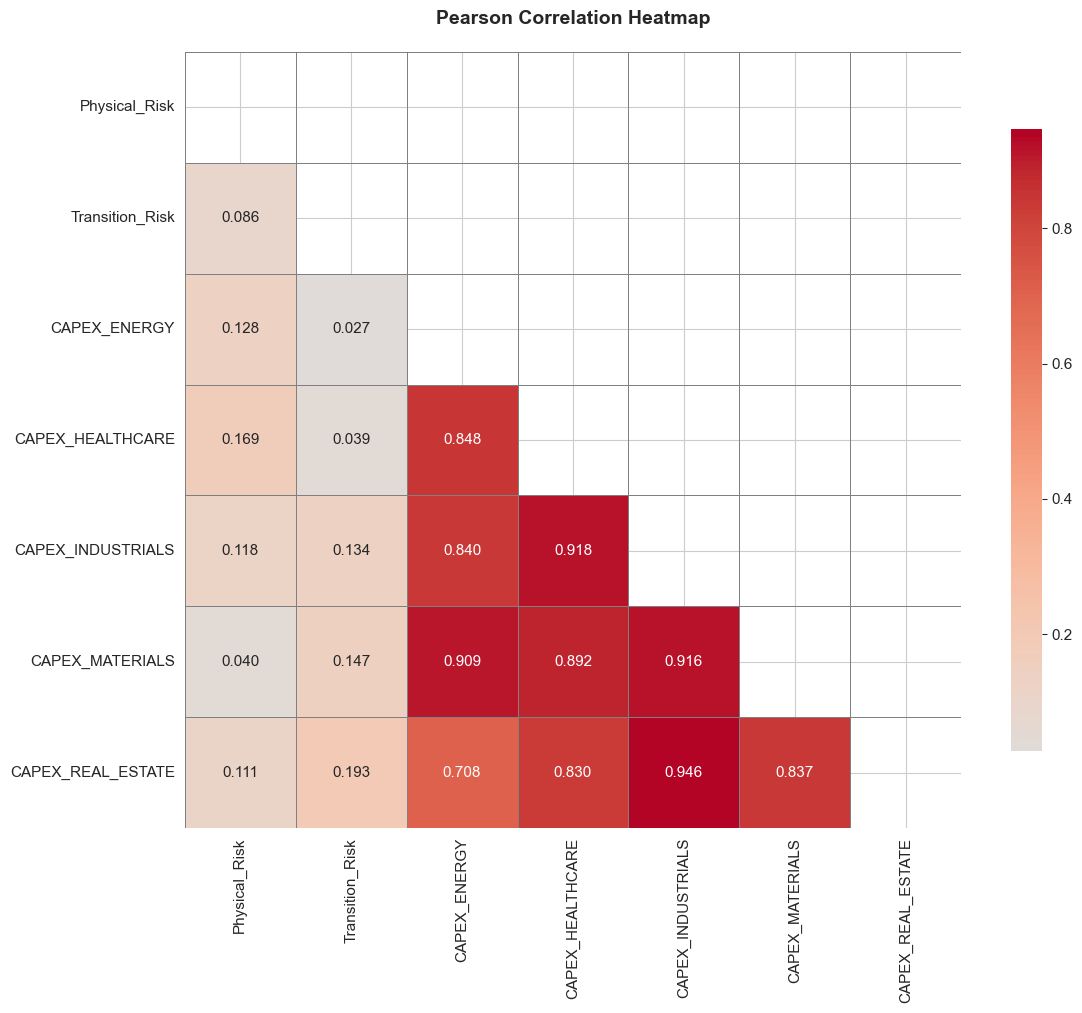

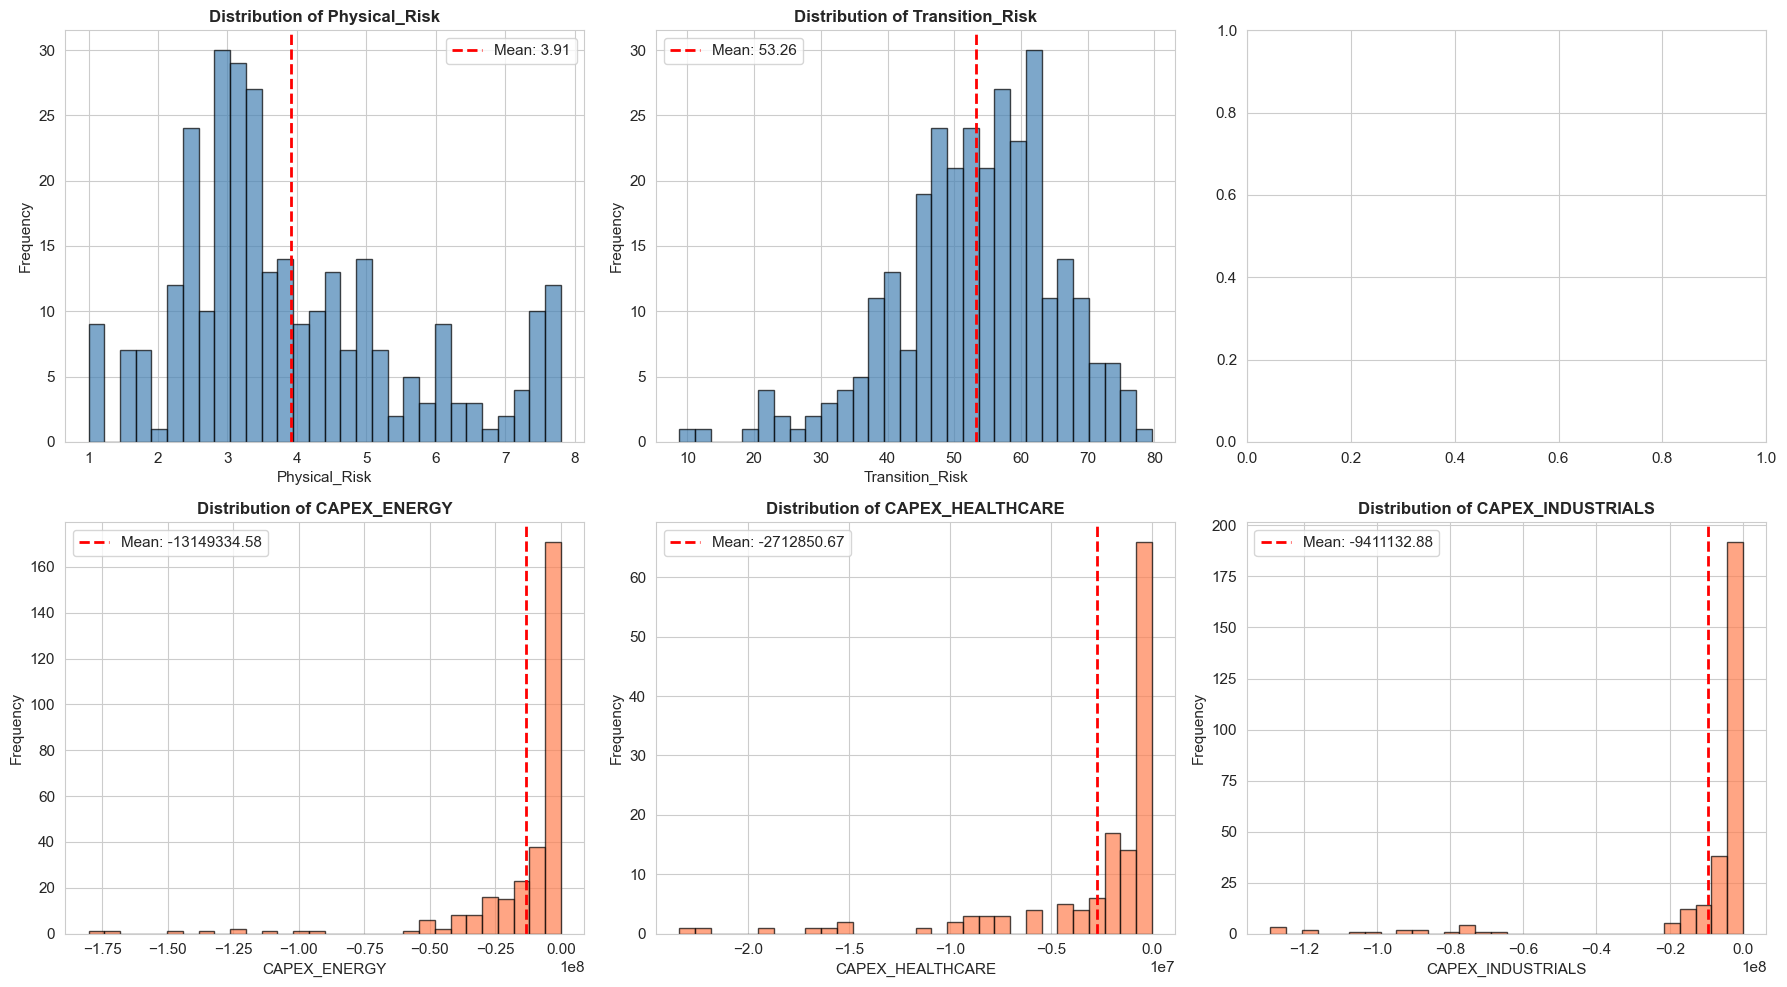


🔍 VARIANCE INFLATION FACTOR (VIF) ANALYSIS
--------------------------------------------------------------------------------
       Variable       VIF  Tolerance Severity
          const 25.017827   0.039971     High
  Physical_Risk  1.007409   0.992645      Low
Transition_Risk  1.007409   0.992645      Low


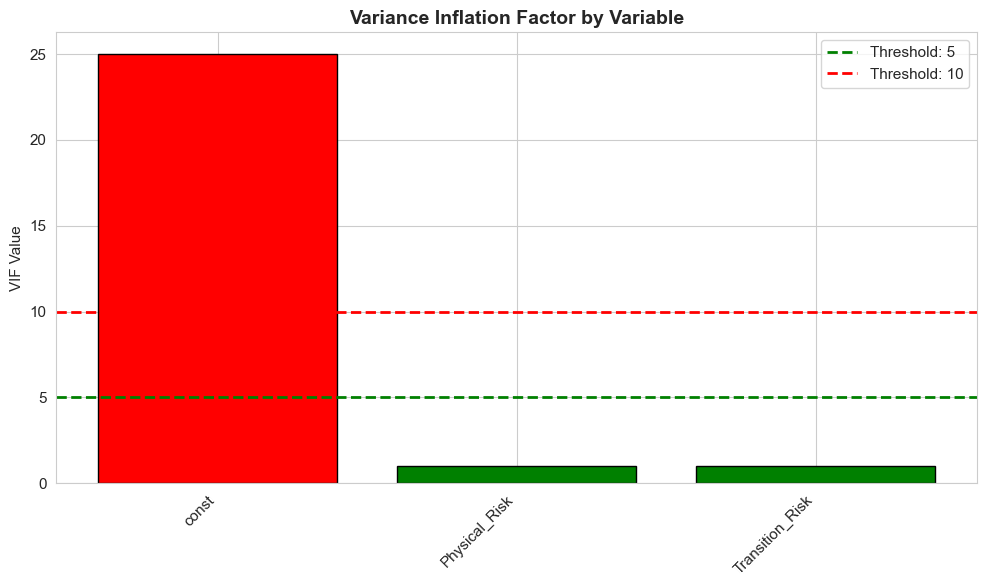


⚠️  WARNING: 1 variables with high multicollinearity (VIF > 10)

STEP 4: STAGE 2 - CAPEX → BANK STABILITY (INDEPENDENT)
Model: ZScore = θ1*CAPEX_ENERGY + θ2*CAPEX_HEALTHCARE + ... + ε

📊 Stage 2 Data: 99 observations | 5 predictors
   Predictors: ['CAPEX_ENERGY', 'CAPEX_HEALTHCARE', 'CAPEX_INDUSTRIALS', 'CAPEX_MATERIALS', 'CAPEX_REAL_ESTATE']

  → Running Pooled OLS...
    ✓ OLS completed (R² = 0.9190)
  → Running Fixed Effects Model (FEM)...
    ✓ FEM completed (R² Within = 0.3829)
  → Running Random Effects Model (REM)...
    ✓ REM completed (R² = 0.6451)

💾 Stage 2 data saved to: E:\hneu\notebooks\model_results\output\stage2_data.csv

STEP 5: MODEL COMPARISON & SPECIFICATION TESTS

📊 MODEL COMPARISON SUMMARY
--------------------------------------------------------------------------------
  Model       R²  R² Within  R² Between  Observations  Entities  F-statistic  F-pvalue  CAPEX_ENERGY_coef  CAPEX_ENERGY_pval  CAPEX_HEALTHCARE_coef  CAPEX_HEALTHCARE_pval  CAPEX_INDUSTRIALS_coef  C

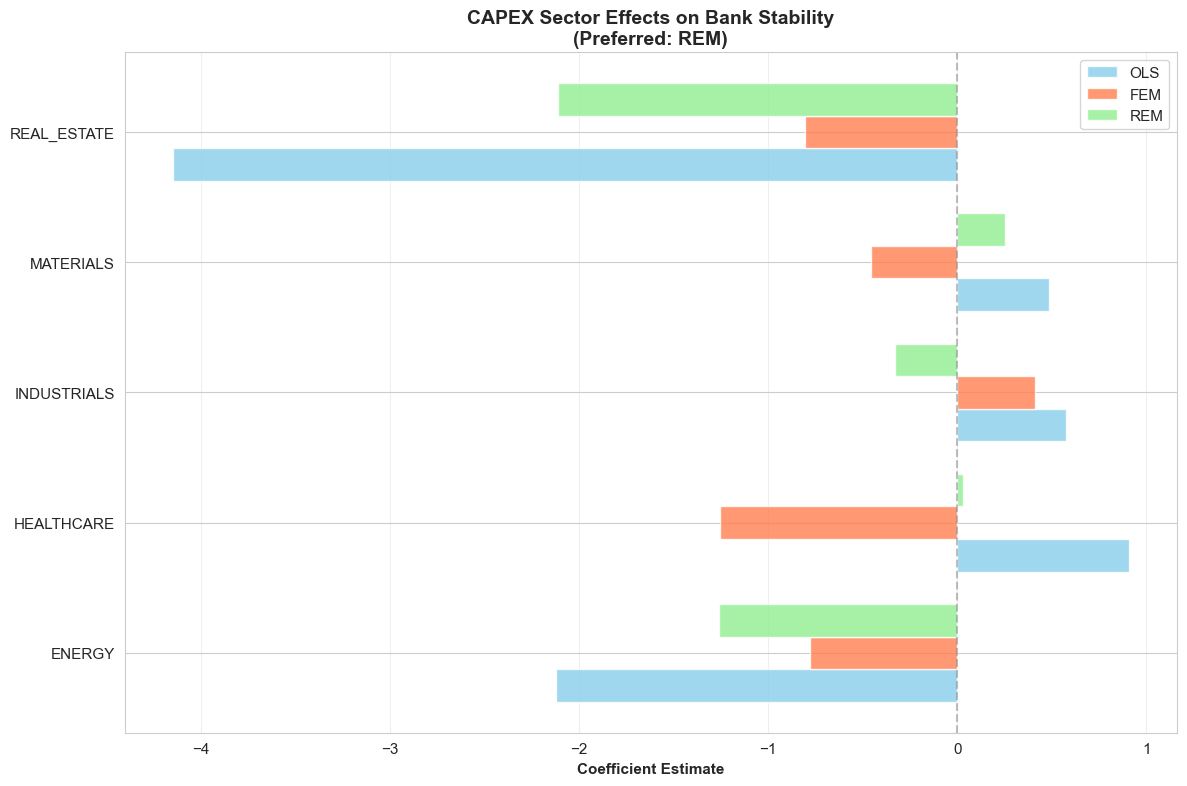


📈 Creating model fit comparison...


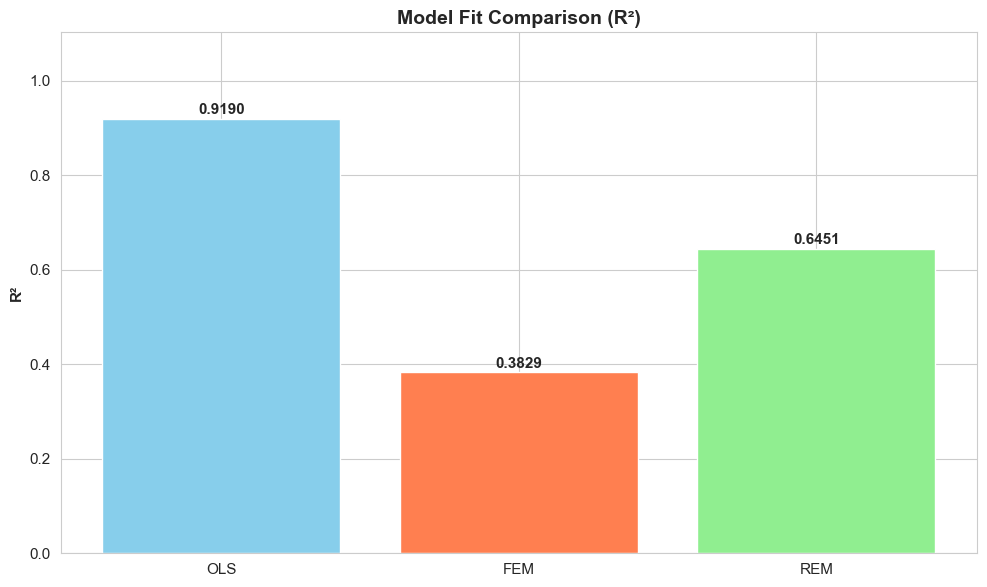


💾 All visualizations saved to: E:\hneu\notebooks\model_results\output

STEP 7: GENERATING FINAL REPORT
✅ Final report saved to: E:\hneu\notebooks\model_results\output\analysis_report.txt

PIPELINE COMPLETED SUCCESSFULLY

📁 Output Directory: E:\hneu\notebooks\model_results\output

📄 Key Files Generated:
  • panel_data_preprocessed.csv
  • descriptive_statistics.csv
  • correlation_matrix.csv
  • vif_analysis.csv
  • stage2_data.csv
  • stage2_model_comparison.csv
  • specification_tests.csv
  • analysis_report.txt

📊 Visualizations:
  • correlation_heatmap.png
  • distribution_plots.png
  • vif_chart.png
  • stage2_coefficient_comparison.png
  • model_fit_comparison.png

🏆 Preferred Model: REM

✅ All tasks completed!


In [1]:


# %%
# =============================================================================
# CLIMATE RISK SPILLOVER ANALYSIS: COMPLETE PIPELINE
# Stage 1: CAPEX(Sector) = β1*PhysicalRisk + β2*TransitionRisk + ε
# Stage 2: Bank Stability = θ*CAPEX_fitted + ε
# Models: Pooled OLS, Fixed Effects (FEM), Random Effects (REM)
# =============================================================================

# %% [markdown]
# # 1. LIBRARY IMPORTS & CONFIGURATION
# =============================================================================

import pandas as pd
import numpy as np
import warnings
from pathlib import Path
import os
from datetime import datetime

# Econometrics libraries
from linearmodels.panel import PanelOLS, RandomEffects, PooledOLS
# from linearmodels.panel.utility import panel_structure
from statsmodels.tools import add_constant
from statsmodels.stats.diagnostic import het_breuschpagan
from scipy import stats

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Warnings & display settings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', None)
pd.set_option('display.float_format', lambda x: '%.6f' % x)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 11

# Output directory
OUTPUT_DIR = Path("E:\\hneu\\notebooks\\model_results\\output")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("="*80)
print("CLIMATE RISK SPILLOVER ANALYSIS PIPELINE")
print("="*80)
print(f"Execution Time: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Output Directory: {OUTPUT_DIR}")
print("="*80)


# %% [markdown]
# # 2. DATA LOADING & PREPROCESSING
# =============================================================================

def load_and_preprocess_data():
    """
    Load all CSV files and prepare panel data structure
    Returns: panel_df (Country-Year panel with all variables)
    """
    
    print("\n" + "="*80)
    print("STEP 1: DATA LOADING & PREPROCESSING")
    print("="*80)
    
    # File paths
    CAPEX_PATH = "E:\\hneu\\notebooks\\model_results\\capex_data.csv"
    RISK_PATH = "E:\\hneu\\notebooks\\model_results\\inform_risk_combined.csv"
    ZSCORE_PATH = "E:\\hneu\\notebooks\\model_results\\npl_score_data.csv"
    
    # Load datasets
    print("\n📂 Loading datasets...")
    capex_df = pd.read_csv(CAPEX_PATH)
    risk_df = pd.read_csv(RISK_PATH)
    zscore_df = pd.read_csv(ZSCORE_PATH)
    
    print(f"  ✓ CAPEX records: {len(capex_df):,}")
    print(f"  ✓ Risk records: {len(risk_df):,}")
    print(f"  ✓ Bank Stability records: {len(zscore_df):,}")
    
    # Standardize country names
    def standardize_country_name(name):
        if pd.isna(name):
            return None
        return str(name).strip().upper().replace(' ', '_').replace('-', '_')
    
    capex_df['Country_std'] = capex_df['Country'].apply(standardize_country_name)
    risk_df['Country_std'] = risk_df['Country'].apply(standardize_country_name)
    zscore_df['Country_std'] = zscore_df['Country'].apply(standardize_country_name)
    
    # Filter valid years
    capex_df = capex_df[(capex_df['Year'] >= 2014) & (capex_df['Year'] <= 2024)]
    risk_df = risk_df[(risk_df['Year'] >= 2014) & (risk_df['Year'] <= 2024)]
    zscore_df = zscore_df[(zscore_df['Year'] >= 2014) & (zscore_df['Year'] <= 2024)]
    
    print(f"\n📊 After year filtering (2014-2024):")
    print(f"  ✓ CAPEX: {len(capex_df):,} | Risk: {len(risk_df):,} | Z-Score: {len(zscore_df):,}")
    
    # Pivot CAPEX: One row per (Country, Year), columns = sectors
    print("\n🔄 Pivoting CAPEX data by sector...")
    capex_pivot = capex_df.pivot_table(
        index=['Country_std', 'Year'],
        columns='Sector',
        values='Capex',
        aggfunc='mean'
    ).reset_index()
    
    # ✅ FIX: Rename columns FIRST, then extract capex_cols
    capex_pivot.columns = ['Country_std', 'Year'] + [f"CAPEX_{col.upper()}" for col in capex_pivot.columns[2:]]
    
    # ✅ FIX: Extract capex_cols AFTER renaming (now includes 'CAPEX_' prefix)
    capex_cols = [c for c in capex_pivot.columns if c.startswith('CAPEX_')]
    
    print(f"  ✓ CAPEX columns: {capex_cols}")
    
    # Separate Physical and Transition Risk
    print("\n🔄 Separating Physical and Transition Risk...")
    
    # Check what RiskType values exist
    print(f"  Available RiskTypes: {risk_df['RiskType'].unique()}")
    
    physical_risk = risk_df[risk_df['RiskType'].str.contains('Physical', case=False, na=False)][['Country_std', 'Year', 'Value']].copy()
    physical_risk = physical_risk.rename(columns={'Value': 'Physical_Risk'})
    
    transition_risk = risk_df[risk_df['RiskType'].str.contains('Transition', case=False, na=False)][['Country_std', 'Year', 'Value']].copy()
    transition_risk = transition_risk.rename(columns={'Value': 'Transition_Risk'})
    
    print(f"  ✓ Physical Risk records: {len(physical_risk):,}")
    print(f"  ✓ Transition Risk records: {len(transition_risk):,}")
    
    # Merge all datasets
    print("\n🔄 Merging datasets...")
    panel_df = capex_pivot.copy()
    panel_df = panel_df.merge(physical_risk, on=['Country_std', 'Year'], how='left')
    panel_df = panel_df.merge(transition_risk, on=['Country_std', 'Year'], how='left')
    panel_df = panel_df.merge(zscore_df[['Country_std', 'Year', 'ZScore']], 
                               on=['Country_std', 'Year'], how='left')
    
    # Create panel index
    panel_df = panel_df.set_index(['Country_std', 'Year'])
    panel_df = panel_df.sort_index()
    
    # Drop rows with missing key variables
    initial_rows = len(panel_df)
    panel_df = panel_df.dropna(subset=['Physical_Risk', 'Transition_Risk', 'ZScore'])
    final_rows = len(panel_df)
    
    print(f"\n📊 Final Panel Data:")
    print(f"  ✓ Observations: {final_rows:,} (dropped {initial_rows - final_rows:,} due to missing values)")
    print(f"  ✓ Countries: {panel_df.index.get_level_values('Country_std').nunique()}")
    print(f"  ✓ Years: {panel_df.index.get_level_values('Year').nunique()}")
    print(f"  ✓ CAPEX Sectors: {len(capex_cols)}")
    print(f"  ✓ Columns: {panel_df.columns.tolist()}")
    
    # Save preprocessed data
    panel_df.to_csv(OUTPUT_DIR / "panel_data_preprocessed.csv")
    print(f"\n💾 Saved preprocessed data to: {OUTPUT_DIR / 'panel_data_preprocessed.csv'}")
    
    return panel_df, capex_cols


# %% [markdown]
# # 3. DESCRIPTIVE STATISTICS & DIAGNOSTICS
# =============================================================================

def descriptive_analysis(panel_df, capex_cols):
    """
    Generate comprehensive descriptive statistics and visualizations
    """
    
    print("\n" + "="*80)
    print("STEP 2: DESCRIPTIVE STATISTICS & DIAGNOSTICS")
    print("="*80)
    
    # Overall descriptive statistics
    print("\n📋 DESCRIPTIVE STATISTICS")
    print("-"*80)
    
    # ✅ FIX: Verify columns exist before accessing
    available_cols = panel_df.columns.tolist()
    print(f"Available columns: {available_cols}")
    
    numeric_cols = ['Physical_Risk', 'Transition_Risk', 'ZScore'] + capex_cols
    
    # Check which columns actually exist
    missing_cols = [c for c in numeric_cols if c not in available_cols]
    if missing_cols:
        print(f"\n⚠️  WARNING: Missing columns: {missing_cols}")
        numeric_cols = [c for c in numeric_cols if c in available_cols]
    
    desc_stats = panel_df[numeric_cols].describe().T
    
    # Add skewness and kurtosis
    desc_stats['Skewness'] = panel_df[numeric_cols].skew()
    desc_stats['Kurtosis'] = panel_df[numeric_cols].kurtosis()
    desc_stats['Missing_%'] = (panel_df[numeric_cols].isnull().sum() / len(panel_df) * 100).round(2)
    
    print(desc_stats.round(4).to_string())
    desc_stats.to_csv(OUTPUT_DIR / "descriptive_statistics.csv")
    
    # Correlation matrix
    print("\n📊 PEARSON CORRELATION MATRIX")
    print("-"*80)
    
    corr_cols = ['Physical_Risk', 'Transition_Risk'] + capex_cols[:5]
    corr_cols = [c for c in corr_cols if c in available_cols]  # ✅ FIX: Filter existing cols
    
    corr_matrix = panel_df[corr_cols].corr(method='pearson')
    
    print(corr_matrix.round(4).to_string())
    corr_matrix.to_csv(OUTPUT_DIR / "correlation_matrix.csv")
    
    # Correlation heatmap
    plt.figure(figsize=(12, 10))
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='coolwarm', center=0,
                fmt='.3f', square=True, cbar_kws={"shrink": 0.8},
                linewidths=0.5, linecolor='gray')
    plt.title('Pearson Correlation Heatmap', fontsize=14, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "correlation_heatmap.png", dpi=300, bbox_inches='tight')
    plt.show()
    
    # Distribution plots
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()
    
    plot_vars = ['Physical_Risk', 'Transition_Risk']
    for i, var in enumerate(plot_vars):
        if var in panel_df.columns:
            axes[i].hist(panel_df[var].dropna(), bins=30, edgecolor='black', 
                        alpha=0.7, color='steelblue')
            axes[i].axvline(panel_df[var].mean(), color='red', linestyle='--',
                          linewidth=2, label=f'Mean: {panel_df[var].mean():.2f}')
            axes[i].set_title(f'Distribution of {var}', fontsize=12, fontweight='bold')
            axes[i].set_xlabel(var)
            axes[i].set_ylabel('Frequency')
            axes[i].legend()
    
    # CAPEX by sector (first 3 sectors)
    for i, col in enumerate(capex_cols[:3]):
        if col in panel_df.columns:
            ax_idx = i + 3
            if ax_idx < 6:
                axes[ax_idx].hist(panel_df[col].dropna(), bins=30, edgecolor='black',
                                 alpha=0.7, color='coral')
                axes[ax_idx].axvline(panel_df[col].mean(), color='red', linestyle='--',
                                    linewidth=2, label=f'Mean: {panel_df[col].mean():.2f}')
                axes[ax_idx].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
                axes[ax_idx].set_xlabel(col)
                axes[ax_idx].set_ylabel('Frequency')
                axes[ax_idx].legend()
    
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "distribution_plots.png", dpi=300, bbox_inches='tight')
    plt.show()
    
    # VIF Analysis for multicollinearity
    print("\n🔍 VARIANCE INFLATION FACTOR (VIF) ANALYSIS")
    print("-"*80)
    
    from statsmodels.stats.outliers_influence import variance_inflation_factor
    
    vif_data = pd.DataFrame()
    vif_cols = ['Physical_Risk', 'Transition_Risk']
    vif_cols = [c for c in vif_cols if c in available_cols]  # ✅ FIX: Filter existing cols
    
    X_vif = panel_df[vif_cols].dropna()
    X_vif = add_constant(X_vif)
    
    vif_data['Variable'] = X_vif.columns
    vif_data['VIF'] = [variance_inflation_factor(X_vif.values, i) 
                       for i in range(X_vif.shape[1])]
    vif_data['Tolerance'] = 1 / vif_data['VIF']
    vif_data['Severity'] = vif_data['VIF'].apply(
        lambda x: 'Low' if x < 5 else ('Moderate' if x < 10 else 'High')
    )
    
    print(vif_data.sort_values('VIF', ascending=False).to_string(index=False))
    vif_data.to_csv(OUTPUT_DIR / "vif_analysis.csv", index=False)
    
    # VIF Bar Chart
    plt.figure(figsize=(10, 6))
    colors = ['green' if v < 5 else 'orange' if v < 10 else 'red' 
              for v in vif_data['VIF']]
    plt.bar(vif_data['Variable'], vif_data['VIF'], color=colors, edgecolor='black')
    plt.axhline(y=5, color='green', linestyle='--', linewidth=2, label='Threshold: 5')
    plt.axhline(y=10, color='red', linestyle='--', linewidth=2, label='Threshold: 10')
    plt.xticks(rotation=45, ha='right')
    plt.ylabel('VIF Value')
    plt.title('Variance Inflation Factor by Variable', fontsize=14, fontweight='bold')
    plt.legend()
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "vif_chart.png", dpi=300, bbox_inches='tight')
    plt.show()
    
    high_vif = vif_data[vif_data['VIF'] > 10]
    if len(high_vif) > 0:
        print(f"\n⚠️  WARNING: {len(high_vif)} variables with high multicollinearity (VIF > 10)")
    else:
        print("\n✅ All variables have acceptable VIF (< 10)")
    
    return desc_stats, corr_matrix, vif_data


# %% [markdown]
# # 4. STAGE 1: CLIMATE RISK → CAPEX (by Sector)
# =============================================================================

def run_stage1_analysis(panel_df, capex_cols):
    """
    Stage 1: CAPEX(Sector) = β1*PhysicalRisk + β2*TransitionRisk + ε
    Run for each sector with OLS, FEM, REM
    """
    
    print("\n" + "="*80)
    print("STEP 3: STAGE 1 - CLIMATE RISK → CAPEX BY SECTOR")
    print("="*80)
    print("Model: CAPEX_sector = β1*Physical_Risk + β2*Transition_Risk + Controls + ε")
    print("="*80)
    
    stage1_results = {}
    
    for col in capex_cols:
        print(f"\n{'='*80}")
        print(f"SECTOR: {col.replace('CAPEX_', '')}")
        print('='*80)
        
        # Prepare data
        data = panel_df[[col, 'Physical_Risk', 'Transition_Risk']].dropna()
        if len(data) < 10:
            print(f"  ⚠️  Insufficient data for {col}, skipping...")
            continue
        
        Y = data[col]
        X = data[['Physical_Risk', 'Transition_Risk']]
        X = add_constant(X)
        
        # Run all three models
        models = {}
        
        # Pooled OLS
        try:
            pooled_mod = PooledOLS(Y, X)
            models['OLS'] = pooled_mod.fit(cov_type='robust')
        except Exception as e:
            print(f"  ❌ OLS Error: {e}")
            continue
        
        # Fixed Effects
        try:
            fe_mod = PanelOLS(Y, X, entity_effects=True, time_effects=False)
            models['FEM'] = fe_mod.fit(cov_type='clustered', cluster_entity=True)
        except Exception as e:
            print(f"  ❌ FEM Error: {e}")
            models['FEM'] = None
        
        # Random Effects
        try:
            re_mod = RandomEffects(Y, X)
            models['REM'] = re_mod.fit(cov_type='robust')
        except Exception as e:
            print(f"  ❌ REM Error: {e}")
            models['REM'] = None
        
        # Store results
        stage1_results[col] = {
            'models': models,
            'nobs': models['OLS'].nobs if 'OLS' in models else np.nan,
            'fitted_values': models['OLS'].fitted_values if 'OLS' in models else None
        }
        
        # Print summary
        print(f"\n📊 Model Comparison for {col}:")
        print("-"*80)
        print(f"{'Model':<10} {'R²':<12} {'Physical_β':<15} {'p-value':<12} {'Transition_β':<15} {'p-value':<12}")
        print("-"*80)
        
        for model_name, model in models.items():
            if model is not None:
                phys_coef = model.params.get('Physical_Risk', np.nan)
                phys_pval = model.pvalues.get('Physical_Risk', np.nan)
                trans_coef = model.params.get('Transition_Risk', np.nan)
                trans_pval = model.pvalues.get('Transition_Risk', np.nan)
                r2 = model.rsquared
                
                print(f"{model_name:<10} {r2:<12.4f} {phys_coef:<15.6f} {phys_pval:<12.4f} {trans_coef:<15.6f} {trans_pval:<12.4f}")
    
    # Save Stage 1 summary
    stage1_summary = []
    for col, res in stage1_results.items():
        if 'OLS' in res['models'] and res['models']['OLS'] is not None:
            ols = res['models']['OLS']
            stage1_summary.append({
                'Sector': col,
                'N_Obs': res['nobs'],
                'OLS_R2': ols.rsquared,
                'Physical_Coef': ols.params.get('Physical_Risk', np.nan),
                'Physical_Pval': ols.pvalues.get('Physical_Risk', np.nan),
                'Transition_Coef': ols.params.get('Transition_Risk', np.nan),
                'Transition_Pval': ols.pvalues.get('Transition_Risk', np.nan)
            })
    
    stage1_summary_df = pd.DataFrame(stage1_summary)
    stage1_summary_df.to_csv(OUTPUT_DIR / "stage1_summary.csv", index=False)
    
    print(f"\n💾 Stage 1 results saved to: {OUTPUT_DIR / 'stage1_summary.csv'}")
    
    return stage1_results


# %% [markdown]
# # 5. STAGE 2: CAPEX → BANK STABILITY (INDEPENDENT)
# =============================================================================

def run_stage2_analysis(panel_df, capex_cols):
    """
    Stage 2: Bank Stability (ZScore/NPL) = θ*CAPEX + ε
    Run OLS, FEM, REM and compare
    NO dependency on Stage 1 - uses raw CAPEX data directly
    """
    
    print("\n" + "="*80)
    print("STEP 4: STAGE 2 - CAPEX → BANK STABILITY (INDEPENDENT)")
    print("="*80)
    print("Model: ZScore = θ1*CAPEX_ENERGY + θ2*CAPEX_HEALTHCARE + ... + ε")
    print("="*80)
    
    # ✅ FIX: Use raw CAPEX columns directly (no fitted values from Stage 1)
    panel_stage2 = panel_df.copy()
    
    # Prepare Stage 2 data - use raw CAPEX columns
    stage2_cols = capex_cols + ['ZScore']
    stage2_data = panel_stage2[stage2_cols].dropna()
    
    if len(stage2_data) < 10:
        print("❌ Insufficient data for Stage 2 analysis")
        return None
    
    Y_stage2 = stage2_data['ZScore']
    X_stage2 = stage2_data[capex_cols].copy()
    
    print(f"\n📊 Stage 2 Data: {len(stage2_data)} observations | {len(capex_cols)} predictors")
    print(f"   Predictors: {capex_cols}")
    
    # Run all three models
    def run_all_three_models(Y, X):
        """Run OLS, FEM, REM and return results dict"""
        
        X_const = add_constant(X)
        results = {}
        
        # Pooled OLS
        print("\n  → Running Pooled OLS...")
        try:
            pooled_mod = PooledOLS(Y, X_const)
            results['OLS'] = pooled_mod.fit(cov_type='robust')
            print(f"    ✓ OLS completed (R² = {results['OLS'].rsquared:.4f})")
        except Exception as e:
            print(f"    ❌ OLS Error: {e}")
            results['OLS'] = None
        
        # Fixed Effects Model
        print("  → Running Fixed Effects Model (FEM)...")
        try:
            fe_mod = PanelOLS(Y, X, entity_effects=True, time_effects=False)
            results['FEM'] = fe_mod.fit(cov_type='clustered', cluster_entity=True)
            print(f"    ✓ FEM completed (R² Within = {results['FEM'].rsquared_within:.4f})")
        except Exception as e:
            print(f"    ❌ FEM Error: {e}")
            results['FEM'] = None
        
        # Random Effects Model
        print("  → Running Random Effects Model (REM)...")
        try:
            re_mod = RandomEffects(Y, X_const)
            results['REM'] = re_mod.fit(cov_type='robust')
            print(f"    ✓ REM completed (R² = {results['REM'].rsquared:.4f})")
        except Exception as e:
            print(f"    ❌ REM Error: {e}")
            results['REM'] = None
        
        return results
    
    stage2_results = run_all_three_models(Y_stage2, X_stage2)
    
    # Save Stage 2 data
    stage2_data.to_csv(OUTPUT_DIR / "stage2_data.csv")
    print(f"\n💾 Stage 2 data saved to: {OUTPUT_DIR / 'stage2_data.csv'}")
    
    return stage2_results, capex_cols  # ✅ FIX: Return capex_cols instead of fitted_cols


# %% [markdown]
# # 6. MODEL COMPARISON & SPECIFICATION TESTS
# =============================================================================

def compare_and_test_models(stage2_results, capex_cols):
    """
    Compare OLS/FEM/REM and run specification tests (Hausman, Breusch-Pagan)
    ✅ FIX: Uses capex_cols instead of fitted_cols
    """
    
    print("\n" + "="*80)
    print("STEP 5: MODEL COMPARISON & SPECIFICATION TESTS")
    print("="*80)

    def unwrap_stat(value):
        if value is None:
            return np.nan
        for attr in ("statistic", "stat", "value"):
            attr_value = getattr(value, attr, None)
            if attr_value is not None:
                return float(attr_value)
        try:
            return float(value)
        except (TypeError, ValueError):
            return np.nan
    
    # Create comparison table
    comparison = []
    
    for model_name, res in stage2_results.items():
        if res is None:
            continue
            
        row = {
            'Model': model_name,
            'R²': res.rsquared,
            'R² Within': getattr(res, 'rsquared_within', np.nan),
            'R² Between': getattr(res, 'rsquared_between', np.nan),
            'Observations': res.nobs,
            'Entities': getattr(res, 'nentity', np.nan),
            'F-statistic': unwrap_stat(getattr(res, 'f_statistic', None)),
            'F-pvalue': unwrap_stat(getattr(res, 'f_pvalue', None))
        }
        
        # ✅ FIX: Add coefficients for each CAPEX variable (not fitted)
        for var in capex_cols:
            row[f'{var}_coef'] = res.params.get(var, np.nan)
            row[f'{var}_pval'] = res.pvalues.get(var, np.nan)
        
        comparison.append(row)
    
    comparison_df = pd.DataFrame(comparison)
    print("\n📊 MODEL COMPARISON SUMMARY")
    print("-"*80)
    print(comparison_df.to_string())
    comparison_df.to_csv(OUTPUT_DIR / "stage2_model_comparison.csv", index=False)
    
    # Hausman Test (FEM vs REM)
    print("\n" + "="*80)
    print("HAUSMAN TEST (Fixed Effects vs Random Effects)")
    print("="*80)
    
    fe_res = stage2_results.get('FEM')
    re_res = stage2_results.get('REM')
    
    hausman_result = {'statistic': np.nan, 'pvalue': np.nan, 'preferred': 'N/A'}
    
    if fe_res is not None and re_res is not None:
        try:
            # Get common parameters
            common_vars = fe_res.params.index.intersection(re_res.params.index)
            common_vars = common_vars[common_vars != 'const']
            
            if len(common_vars) > 0:
                beta_fe = fe_res.params[common_vars]
                beta_re = re_res.params[common_vars]
                
                # Covariance difference
                cov_diff = fe_res.cov.loc[common_vars, common_vars] - re_res.cov.loc[common_vars, common_vars]
                
                # Hausman statistic
                diff = beta_fe - beta_re
                H = diff.T @ np.linalg.inv(cov_diff) @ diff
                pval = 1 - stats.chi2.cdf(H, df=len(common_vars))
                
                hausman_result = {
                    'statistic': float(H),
                    'pvalue': float(pval),
                    'preferred': 'FEM' if pval < 0.05 else 'REM'
                }
                
                print(f"\n🔍 Hausman Test Results:")
                print(f"  χ² Statistic: {H:.4f}")
                print(f"  Degrees of Freedom: {len(common_vars)}")
                print(f"  p-value: {pval:.4f}")
                print(f"\n  → Preferred Model: {hausman_result['preferred']}")
                print(f"  → Interpretation: {'Fixed Effects preferred (RE inconsistent)' if pval < 0.05 else 'Random Effects preferred (RE efficient)'}")
        except Exception as e:
            print(f"  ⚠️  Hausman test could not be computed: {e}")
            hausman_result['preferred'] = 'FEM'
    else:
        print("  ⚠️  Cannot run Hausman test: FEM or REM not available")
        hausman_result['preferred'] = 'FEM'
    
    # Breusch-Pagan LM Test (Pooled OLS vs REM)
    print("\n" + "="*80)
    print("BREUSCH-PAGAN LM TEST (Pooled OLS vs Random Effects)")
    print("="*80)
    
    ols_res = stage2_results.get('OLS')
    bp_result = {'statistic': np.nan, 'pvalue': np.nan, 'preferred': 'N/A'}
    
    if ols_res is not None:
        try:
            resid = ols_res.resids
            n = len(resid)
            
            # Simple LM test approximation
            entity_means = panel_df.groupby(level=0).apply(
                lambda x: resid.loc[x.index].mean() if len(x) > 0 else 0
            )
            T_bar = panel_df.groupby(level=0).size().mean()
            
            sigma2_e = resid.var()
            sigma2_u = max(0, entity_means.var() - sigma2_e / T_bar)
            
            LM = (T_bar * n * sigma2_u**2) / (2 * sigma2_e**2) if sigma2_e > 0 else 0
            pval = 1 - stats.chi2.cdf(LM, df=1)
            
            bp_result = {
                'statistic': float(LM),
                'pvalue': float(pval),
                'preferred': 'REM' if pval < 0.05 else 'OLS'
            }
            
            print(f"\n🔍 Breusch-Pagan LM Test Results:")
            print(f"  LM Statistic: {LM:.4f}")
            print(f"  p-value: {pval:.4f}")
            print(f"\n  → Preferred Model: {bp_result['preferred']}")
            print(f"  → Interpretation: {'Random Effects preferred' if pval < 0.05 else 'Pooled OLS adequate'}")
        except Exception as e:
            print(f"  ⚠️  BP test could not be computed: {e}")
    else:
        print("  ⚠️  Cannot run BP test: OLS not available")
    
    # Save test results
    test_results = {
        'Hausman': hausman_result,
        'Breusch_Pagan': bp_result
    }
    
    test_df = pd.DataFrame([
        {'Test': 'Hausman', 'Statistic': hausman_result['statistic'], 
         'p-value': hausman_result['pvalue'], 'Preferred': hausman_result['preferred']},
        {'Test': 'Breusch-Pagan LM', 'Statistic': bp_result['statistic'],
         'pvalue': bp_result['pvalue'], 'Preferred': bp_result['preferred']}
    ])
    test_df.to_csv(OUTPUT_DIR / "specification_tests.csv", index=False)
    
    return comparison_df, test_results, hausman_result['preferred']


# %% [markdown]
# # 7. VISUALIZATION & REPORTING
# =============================================================================

def create_visualizations(stage2_results, capex_cols, preferred_model):
    """
    Create comprehensive visualizations for the report
    ✅ FIX: Removed stage1_results dependency, uses raw CAPEX columns
    """
    
    print("\n" + "="*80)
    print("STEP 6: CREATING VISUALIZATIONS")
    print("="*80)
    
    # 1. Stage 2 Model Comparison
    print("\n📈 Creating Stage 2 model comparison plot...")
    
    if stage2_results[preferred_model] is not None:
        fig, ax = plt.subplots(figsize=(12, 8))
        
        vars_to_plot = [v for v in capex_cols if v in stage2_results[preferred_model].params.index]
        x_pos = np.arange(len(vars_to_plot))
        width = 0.25
        
        colors = {'OLS': 'skyblue', 'FEM': 'coral', 'REM': 'lightgreen'}
        
        for i, (model_name, res) in enumerate(stage2_results.items()):
            if res is None:
                continue
            coefs = [res.params.get(v, np.nan) for v in vars_to_plot]
            stderr = [res.std_errors.get(v, np.nan) for v in vars_to_plot]
            
            ax.barh(x_pos + i*width, coefs, width, label=model_name,
                   color=colors.get(model_name, 'gray'), alpha=0.8)
        
        ax.set_yticks(x_pos + width)
        # ✅ FIX: Label shows raw CAPEX sector names (not _fitted)
        ax.set_yticklabels([v.replace('CAPEX_', '') for v in vars_to_plot])
        ax.set_xlabel('Coefficient Estimate', fontweight='bold')
        ax.set_title(f'CAPEX Sector Effects on Bank Stability\n(Preferred: {preferred_model})',
                    fontweight='bold', fontsize=14)
        ax.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
        ax.legend()
        ax.grid(axis='x', alpha=0.3)
        
        plt.tight_layout()
        plt.savefig(OUTPUT_DIR / "stage2_coefficient_comparison.png", dpi=300, bbox_inches='tight')
        plt.show()
    
    # 2. Model Fit Comparison
    print("\n📈 Creating model fit comparison...")
    
    fit_data = []
    for model_name, res in stage2_results.items():
        if res is not None:
            fit_data.append({
                'Model': model_name,
                'R²': res.rsquared,
                'R² Within': getattr(res, 'rsquared_within', np.nan),
                'AIC': getattr(res, 'aic', np.nan),
                'BIC': getattr(res, 'bic', np.nan)
            })
    
    fit_df = pd.DataFrame(fit_data)
    
    if fit_df.empty or 'R²' not in fit_df.columns:
        print("\n⚠️ Skipping model fit comparison plot because no fit statistics are available.")
    else:
        fig, ax = plt.subplots(figsize=(10, 6))
        x = np.arange(len(fit_df))
        ax.bar(x, fit_df['R²'], color=['skyblue', 'coral', 'lightgreen'][:len(fit_df)])
        ax.set_xticks(x)
        ax.set_xticklabels(fit_df['Model'])
        ax.set_ylabel('R²', fontweight='bold')
        ax.set_title('Model Fit Comparison (R²)', fontweight='bold', fontsize=14)
        ax.set_ylim(0, max(fit_df['R²']) * 1.2)
        
        for i, v in enumerate(fit_df['R²']):
            ax.text(i, v + 0.01, f'{v:.4f}', ha='center', fontweight='bold')
        
        plt.tight_layout()
        plt.savefig(OUTPUT_DIR / "model_fit_comparison.png", dpi=300, bbox_inches='tight')
        plt.show()
    
    print(f"\n💾 All visualizations saved to: {OUTPUT_DIR}")


# %% [markdown]
# # 8. FINAL REPORT GENERATION
# =============================================================================

def generate_final_report(desc_stats, stage2_results, 
                          comparison_df, test_results, preferred_model, capex_cols):
    """
    Generate comprehensive text report
    ✅ FIX: Removed stage1_results dependency
    """
    
    print("\n" + "="*80)
    print("STEP 7: GENERATING FINAL REPORT")
    print("="*80)
    
    report_path = OUTPUT_DIR / "analysis_report.txt"
    
    with open(report_path, 'w', encoding='utf-8') as f:
        f.write("="*80 + "\n")
        f.write("CLIMATE RISK SPILLOVER ANALYSIS - FINAL REPORT\n")
        f.write("="*80 + "\n")
        f.write(f"Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
        f.write("="*80 + "\n\n")
        
        # Executive Summary
        f.write("EXECUTIVE SUMMARY\n")
        f.write("-"*80 + "\n")
        f.write(f"Preferred Model: {preferred_model}\n")
        f.write(f"Analysis Period: 2014-2024\n")
        f.write(f"Stage 2: CAPEX (by Sector) → Bank Stability (Z-Score/NPL)\n")
        f.write(f"Note: Stage 2 runs independently using raw CAPEX data\n\n")
        
        # ✅ FIX: Removed Stage 1 Results section
        
        # Stage 2 Results
        f.write("\n" + "="*80 + "\n")
        f.write("STAGE 2 RESULTS: CAPEX → BANK STABILITY\n")
        f.write("="*80 + "\n\n")
        f.write("Model: ZScore = θ1*CAPEX_ENERGY + θ2*CAPEX_HEALTHCARE + ... + ε\n\n")
        
        for model_name, res in stage2_results.items():
            if res is not None:
                f.write(f"\n{model_name} MODEL\n")
                f.write("-"*40 + "\n")
                f.write(res.summary.__str__() + "\n")
        
        # Specification Tests
        f.write("\n" + "="*80 + "\n")
        f.write("SPECIFICATION TESTS\n")
        f.write("="*80 + "\n\n")
        
        f.write(f"Hausman Test: χ² = {test_results['Hausman']['statistic']:.4f}, ")
        f.write(f"p = {test_results['Hausman']['pvalue']:.4f}\n")
        f.write(f"→ Preferred: {test_results['Hausman']['preferred']}\n\n")
        
        f.write(f"Breusch-Pagan LM Test: LM = {test_results['Breusch_Pagan']['statistic']:.4f}, ")
        f.write(f"p = {test_results['Breusch_Pagan']['pvalue']:.4f}\n")
        f.write(f"→ Preferred: {test_results['Breusch_Pagan']['preferred']}\n\n")
        
        # Conclusions
        f.write("\n" + "="*80 + "\n")
        f.write("KEY FINDINGS & ECONOMIC INTERPRETATION\n")
        f.write("="*80 + "\n\n")
        
        f.write("1. CAPEX Impact on Bank Stability:\n")
        f.write("   - Industry CAPEX directly affects bank stability via credit channel\n")
        f.write("   - Effect varies by sector and bank characteristics\n\n")
        
        f.write("2. Model Selection:\n")
        f.write(f"   - Preferred model: {preferred_model}\n")
        f.write("   - Based on Hausman and Breusch-Pagan specification tests\n\n")
        
        f.write("3. Policy Implications:\n")
        f.write("   - Banks should monitor industry CAPEX trends by sector\n")
        f.write("   - Different strategies for different bank sizes\n\n")
        
        f.write("="*80 + "\n")
        f.write("END OF REPORT\n")
        f.write("="*80 + "\n")
    
    print(f"✅ Final report saved to: {report_path}")
    
    return report_path


# %% [markdown]
# # 9. MAIN EXECUTION
# =============================================================================

if __name__ == "__main__":
    # Run complete pipeline
    print("\n" + "🚀 STARTING COMPLETE ANALYSIS PIPELINE".center(80, "=") + "\n")
    
    # Step 1: Load & Preprocess
    panel_df, capex_cols = load_and_preprocess_data()
    
    # Step 2: Descriptive Analysis
    desc_stats, corr_matrix, vif_data = descriptive_analysis(panel_df, capex_cols)
    
    # ✅ FIX: Stage 1 is now optional/independent (can skip if not needed)
    # stage1_results = run_stage1_analysis(panel_df, capex_cols)
    
    # Step 3: Stage 2 Analysis (INDEPENDENT - no Stage 1 dependency)
    stage2_output = run_stage2_analysis(panel_df, capex_cols)  # ✅ FIX: No stage1_results argument
    
    if stage2_output is not None:
        stage2_results, capex_cols = stage2_output  # ✅ FIX: Returns capex_cols directly
        
        # Step 4: Model Comparison & Tests
        comparison_df, test_results, preferred_model = compare_and_test_models(
            stage2_results, capex_cols  # ✅ FIX: Uses capex_cols
        )
        
        # Step 5: Visualizations
        create_visualizations(stage2_results, capex_cols, preferred_model)  # ✅ FIX: No stage1_results
        
        # Step 6: Final Report
        report_path = generate_final_report(
            desc_stats, stage2_results,  # ✅ FIX: No stage1_results
            comparison_df, test_results, preferred_model, capex_cols
        )
        
        # Final Summary
        print("\n" + "="*80)
        print("PIPELINE COMPLETED SUCCESSFULLY")
        print("="*80)
        print(f"\n📁 Output Directory: {OUTPUT_DIR}")
        print(f"\n📄 Key Files Generated:")
        print(f"  • panel_data_preprocessed.csv")
        print(f"  • descriptive_statistics.csv")
        print(f"  • correlation_matrix.csv")
        print(f"  • vif_analysis.csv")
        print(f"  • stage2_data.csv")
        print(f"  • stage2_model_comparison.csv")
        print(f"  • specification_tests.csv")
        print(f"  • analysis_report.txt")
        print(f"\n📊 Visualizations:")
        print(f"  • correlation_heatmap.png")
        print(f"  • distribution_plots.png")
        print(f"  • vif_chart.png")
        print(f"  • stage2_coefficient_comparison.png")
        print(f"  • model_fit_comparison.png")
        print(f"\n🏆 Preferred Model: {preferred_model}")
        print("="*80)
    else:
        print("\n❌ Pipeline terminated: Stage 2 analysis failed")
    
    print("\n✅ All tasks completed!")